# Стабильность регрессионных моделей во времени — ФИНАЛЬНЫЙ ноутбук

**Курсовая работа.** Прогноз количества часов, проведённых пользователем в игре
за следующие 30 дней (`target_hours_next_30d`). Эта величина прямо связана с
рекламным доходом от пользователя: чем дольше играет, тем больше показов
рекламы, тем выше LTV.

**Цель:** изучить **стабильность модели во времени**, её деградацию на новых
snapshot-датах и найти **компромисс между качеством и стабильностью**.
Сравниваем три параметрических семейства: линейная регрессия (Ridge),
градиентный бустинг (LightGBM) и нейросеть (MLPRegressor из sklearn).

**Что в ноутбуке:**
1. Загрузка, EDA (распределение target, дрейф по времени, covariate drift).
2. Split: train (7 первых снэпшотов) + val (4 переходных) + test (7 поздних).
3. **Три явных Baseline-раздела** — Ridge / LightGBM / MLP, каждый показывает
   собственные кривые **val и test** на графиках Spearman / RMSE.
4. Диагностика дрейфа: PSI + adversarial validation + важность признаков.
5. Углублённое исследование линейной модели (5 вариантов).
6. Углублённое исследование LightGBM (7 экспериментов).
7. **Per-model window sweep**: каждая из трёх моделей подбирает СВОЁ
   оптимальное окно для sliding-режима — это ключевое нововведение.
8. Финальное 3-way сравнение на персональных окнах.
9. BASELINE vs EXTENDED наборы признаков.
10. Подробные выводы для отчёта.

**Главная метрика — Spearman** (ранговая корреляция). Она лучше отражает
практическую цель (ранжирование пользователей по будущему доходу) и устойчива
к выбросам — «китам», которые искажают RMSE. Дополнительно выводим
RMSE / MAE / R² для полноты.

**Что осталось вне этого ноутбука:** углублённое исследование MLP в стиле
deep-dive (как у LightGBM) — оно есть в отдельном файле `nn_stability.ipynb`,
и для PyTorch-варианта с кастомными loss-функциями требует значительно больше
кода.

In [1]:
# ВАЖНО: env-переменные для OpenMP должны быть установлены ДО импорта numpy/lightgbm/sklearn,
# иначе на macOS возможны deadlock'и при конфликте OpenMP-библиотек (см. issue
# https://github.com/openmp/openmp/issues/178 и т.п.).
import os
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor

# Линейная буферизация stdout — иначе print не доходит до tee/файла, пока буфер не заполнится
try:
    sys.stdout.reconfigure(line_buffering=True)
except Exception:
    pass
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "/Users/dmitrijmitrhin/Desktop/MLGameDev/snapshot_extended_final.parquet"
ART_DIR = "/Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final"
os.makedirs(ART_DIR, exist_ok=True)

H = 30                  # горизонт таргета, дней
CAP = H * 24.0          # потолок — 720 часов
LOG_CAP = np.log1p(CAP)

# Для MLP используем sklearn.MLPRegressor (надёжно, без OpenMP-конфликтов на macOS).
# Чтобы скорость была приемлемой:
#   - архитектуру держим маленькой (один-два скрытых слоя по 64);
#   - max_iter ограничен, early_stopping=True;
#   - в static-режиме модель кэшируется и обучается один раз на 7 train снэпшотах,
#     потом просто предсказывает на val + test (см. temporal_eval).
np.random.seed(RANDOM_STATE)

# Для встраивания графиков в jupyter
try:
    from IPython.display import display as _ipy_display
    _IN_IPY = True
except Exception:
    _IN_IPY = False


def save_fig(name):
    """Сохраняет фигуру в artifacts_final/ и (если запущено в jupyter) показывает inline."""
    path = os.path.join(ART_DIR, name)
    fig = plt.gcf()
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"  [saved] {path}")
    if _IN_IPY:
        _ipy_display(fig)
    plt.close(fig)

## Вспомогательные функции

- `metrics(y, p)` — четыре метрики в одном словаре: MAE, RMSE, R², Spearman.
- `stability_row(name, curves, split)` — сводный показатель по кривой
  (метрики по snapshot-датам): `Spearman_mean` (качество), `Spearman_std`
  и `stability = 1/(1+std)` (стабильность), `slope` (наклон линейного
  тренда — скорость деградации), `R2_mean`, `RMSE_mean`, `MAE_mean`.

Параметр `split` фильтрует кривую по подмножеству `'val'` или `'test'`.

In [2]:
def metrics(y, p):
    """4 метрики на одной выборке: MAE, RMSE, R², Spearman."""
    return {
        "MAE": float(mean_absolute_error(y, p)),
        "RMSE": float(np.sqrt(mean_squared_error(y, p))),
        "R2": float(r2_score(y, p)) if np.var(y) > 0 else np.nan,
        "Spearman": float(spearmanr(y, p).correlation) if (np.var(y) > 0 and np.var(p) > 0) else np.nan,
    }


def stability_row(name, curves, split=None):
    """Сводный показатель по одной модели/эксперименту.
    Если split задан, фильтруем кривую по нему ('val' или 'test')."""
    if len(curves) == 0:
        return None
    c = curves if split is None else curves[curves["split"] == split]
    if len(c) == 0:
        return None
    sp = c["Spearman"].dropna().values
    r2 = c["R2"].dropna().values
    rm = c["RMSE"].dropna().values
    ma = c["MAE"].dropna().values
    return {
        "model": name,
        "Spearman_mean": float(sp.mean()) if len(sp) else np.nan,
        "Spearman_std": float(sp.std()) if len(sp) >= 2 else 0.0,
        "stability": float(1 / (1 + (sp.std() if len(sp) >= 2 else 0.0))),
        "slope": float(np.polyfit(range(len(sp)), sp, 1)[0]) if len(sp) >= 2 else 0.0,
        "R2_mean": float(np.nanmean(r2)) if len(r2) else np.nan,
        "RMSE_mean": float(rm.mean()) if len(rm) else np.nan,
        "MAE_mean": float(ma.mean()) if len(ma) else np.nan,
    }

## Подготовка признаков для линейной модели

`prep_X_for_linear(...)` — простая обёртка без `sklearn.Pipeline`. Что делает:

1. **Числовые** → signed `log1p` (если `use_log=True`): сжимает тяжёлые
   распределения, устойчиво к отрицательным значениям;
2. **Низкокардинальные категории** (`device_type`, `connection_type`) →
   one-hot через `pd.get_dummies`;
3. **Высококардинальные** (`country_iso_code`, `app_version_name`) →
   частотное кодирование (заменяем значение на его частоту в train);
4. **Стандартизация** (StandardScaler) — фитим только на train, применяем к test.

Для LightGBM такой препроцессинг не нужен: бустинг работает напрямую с
категориальными признаками (`categorical_feature=...`) и нечувствителен
к шкале числовых.

In [3]:
def prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True):
    """Готовит X_train, X_test для линейной модели.

    - Числовые: знаковый log1p (если use_log), без NaN/inf.
    - Низкокардинальные категории (device, connection): one-hot через get_dummies.
    - Высококардинальные (country, app_version): частотное кодирование (частоты по train).
    - Финальная стандартизация по train.
    """
    tr_num = tr[num_cols].astype(np.float32).fillna(0.0).values
    te_num = te[num_cols].astype(np.float32).fillna(0.0).values
    if use_log:
        tr_num = np.sign(tr_num) * np.log1p(np.abs(tr_num))
        te_num = np.sign(te_num) * np.log1p(np.abs(te_num))

    combined_low = pd.concat([tr[low_cols], te[low_cols]], axis=0).astype(str)
    dummies = pd.get_dummies(combined_low, drop_first=False).astype(np.float32)
    tr_low = dummies.iloc[:len(tr)].values
    te_low = dummies.iloc[len(tr):].values

    tr_high_parts, te_high_parts = [], []
    for c in high_cols:
        freq = tr[c].astype(str).value_counts(normalize=True).to_dict()
        tr_high_parts.append(tr[c].astype(str).map(freq).fillna(0.0).values.astype(np.float32))
        te_high_parts.append(te[c].astype(str).map(freq).fillna(0.0).values.astype(np.float32))
    tr_high = np.column_stack(tr_high_parts) if tr_high_parts else np.zeros((len(tr), 0), dtype=np.float32)
    te_high = np.column_stack(te_high_parts) if te_high_parts else np.zeros((len(te), 0), dtype=np.float32)

    X_tr = np.hstack([tr_num, tr_low, tr_high]).astype(np.float32)
    X_te = np.hstack([te_num, te_low, te_high]).astype(np.float32)
    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    return X_tr, X_te

## Нейросеть: sklearn MLPRegressor

`make_mlp(hidden=(64, 32), max_iter=25, alpha=1e-3)` — конструктор небольшого
`MLPRegressor` со стандартными настройками.

Почему именно sklearn (а не PyTorch):
- На Python 3.14 + macOS у нас наблюдались зависания PyTorch (MPS-deadlock,
  OpenMP-конфликты) после серии операций. sklearn-вариант работает стабильно.
- Архитектура маленькая `(64, 32)`, log-таргет, ReLU, Adam, batch_size=512,
  early stopping. Этого хватает для нашей задачи и существенно проще, чем
  кастомный PyTorch train-loop.

Препроцессинг для MLP — тот же `prep_X_for_linear`, что и для Ridge:
one-hot для низкокардинальных категорий, частотное кодирование для
высококардинальных, signed-log для числовых, потом StandardScaler. Это
позволяет переиспользовать готовый код без отдельного PyTorch-классов.

Для скорости в static-режиме модель кэшируется и обучается один раз на
train (см. `_fit_and_predict_one_date`); потом тот же `m.predict(X_te)`
применяется к каждой eval-дате. Это критично, потому что один fit MLP
на 880 тыс. строк занимает 30–90 с, а нам нужно 11 предсказаний.

In [4]:
def make_mlp(hidden=(64, 32), max_iter=25, alpha=1e-3):
    """Простой конструктор sklearn-MLPRegressor с разумными дефолтами.

    Параметры подобраны для скорости + надёжности:
    - hidden_layer_sizes=(64, 32) — маленькая сеть, обучается за ~30-60s на 880k строк;
    - alpha=1e-3 — L2-регуляризация;
    - max_iter ограничен — early_stopping=True останавливает раньше;
    - batch_size=auto (sklearn выбирает разумный) — для нашего размера ~200;
    - solver='adam' — обычно лучший для табличных данных;
    - random_state=42 для воспроизводимости.

    Препроцессинг (one-hot/частотное кодирование + стандартизация) делается через
    общий prep_X_for_linear — те же самые X, что для Ridge, но с log_target=True.
    """
    return MLPRegressor(
        hidden_layer_sizes=hidden,
        activation="relu",
        solver="adam",
        alpha=alpha,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=max_iter,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
        verbose=False,
    )

## Главный цикл оценки — `temporal_eval`

Функция, которая обходит snapshot-даты и для каждой:
1. Готовит train (по `mode='static'` — всё до `train_end`; по `'sliding'` —
   окно длины `train_win_days` непосредственно перед `date - purge`);
2. Готовит test = одна snapshot-дата;
3. Подготавливает X в зависимости от `model_kind`:
   - `lgbm`: категории как `category` dtype, LightGBM обрабатывает нативно;
   - `linear` / `ridge`: через `prep_X_for_linear`;
   - `mlp`: через `TabularPreprocessor` + PyTorch.
4. Обучает модель, предсказывает, клипает в `[0, CAP]`;
5. Считает метрики `metrics(y, p)`, пишет строку в результирующий DataFrame.

Ключевой параметр — **`val_dates`** и **`test_dates`** (списки дат). Колонка
`split` в результате помечает каждую строку как `'val'` или `'test'`. Это
позволяет на одном графике показать обе кривые с разной стилизацией.

In [5]:
def _fit_and_predict_one_date(df, tr_mask, te, num_cols, low_cols, high_cols, model_kind,
                                log_target, use_log_num, lgb_params, alpha,
                                mlp_hidden, mlp_epochs,
                                _cache=None):
    """Внутренний хелпер: один train+predict для одной test-даты.

    Если model_kind ∈ {'linear','ridge','lgbm'} — фитим заново. Эти модели быстрые.
    Для 'mlp' дорого, поэтому если _cache содержит готовую модель + препроцессор
    с тем же train_mask_hash, переиспользуем (важно для static-режима, где
    train одинаковый для всех eval-дат).
    """
    tr = df[tr_mask]
    y_tr = tr["target_hours_next_30d"].astype(np.float32).values
    y_te = te["target_hours_next_30d"].astype(np.float32).values

    if model_kind == "lgbm":
        feat_cols = num_cols + low_cols + high_cols
        X_tr_df = tr[feat_cols].copy()
        X_te_df = te[feat_cols].copy()
        for c in low_cols + high_cols:
            X_tr_df[c] = X_tr_df[c].astype("category")
            X_te_df[c] = X_te_df[c].astype("category")
        # Кэш модели для static-режима (train один и тот же)
        if _cache is not None and _cache.get("model") is not None:
            m = _cache["model"]
        else:
            y_fit = np.log1p(np.clip(y_tr, 0, None)) if log_target else y_tr
            m = lgb.LGBMRegressor(**dict(lgb_params or {}))
            m.fit(X_tr_df, y_fit, categorical_feature=low_cols + high_cols)
            if _cache is not None:
                _cache["model"] = m
        p = m.predict(X_te_df)
        if log_target:
            p = np.expm1(np.clip(p, None, LOG_CAP))
        return np.clip(p, 0, CAP), y_te

    if model_kind in ("linear", "ridge"):
        if _cache is not None and _cache.get("model") is not None:
            # Готовая модель и тот же scaler → пересчёт только для test
            # Для простоты всё-таки фитим препроцессинг заново (быстро),
            # модель не пересоздаём
            _, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=use_log_num)
            m = _cache["model"]
        else:
            X_tr, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=use_log_num)
            y_fit = np.log1p(np.clip(y_tr, 0, None)) if log_target else y_tr
            m = LinearRegression() if model_kind == "linear" else Ridge(alpha=alpha, random_state=RANDOM_STATE)
            m.fit(X_tr, y_fit)
            if _cache is not None:
                _cache["model"] = m
        p = m.predict(X_te)
        if log_target:
            p = np.expm1(np.clip(p, None, LOG_CAP))
        return np.clip(p, 0, CAP), y_te

    if model_kind == "mlp":
        # Используем то же preprocessing, что для Ridge (one-hot + frequency + scaling)
        # и sklearn.MLPRegressor с log-таргетом — простая, надёжная схема.
        if _cache is not None and _cache.get("model") is not None:
            m = _cache["model"]
            # Препроцессинг для test делаем заново (быстро), train не нужен
            _, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True)
        else:
            X_tr, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True)
            y_fit = np.log1p(np.clip(y_tr, 0, None))
            m = make_mlp(hidden=mlp_hidden, max_iter=mlp_epochs)
            m.fit(X_tr, y_fit)
            if _cache is not None:
                _cache["model"] = m
        p = m.predict(X_te)
        p = np.expm1(np.clip(p, None, LOG_CAP))
        return np.clip(p, 0, CAP), y_te

    raise ValueError(f"Unknown model_kind: {model_kind}")


def temporal_eval(df, num_cols, low_cols, high_cols, model_kind,
                  train_end, mode="static", train_win_days=42,
                  val_dates=None, test_dates=None,
                  log_target=True, use_log_num=True,
                  lgb_params=None, alpha=3.0,
                  mlp_hidden=(64, 32), mlp_epochs=25,
                  verbose=False):
    """Главный цикл оценки модели по snapshot-датам.

    model_kind: 'linear', 'ridge', 'lgbm', 'mlp'.
    mode: 'static' — обучаем модель ОДИН РАЗ на train и предсказываем все
          eval-даты (модель кэшируется).
    mode: 'sliding' — для каждой eval-даты обучаем заново на окне `train_win_days`
          перед `date - purge`.
    """
    purge = pd.Timedelta(days=H)
    if val_dates is None:
        val_dates = []
    if test_dates is None:
        test_dates = []
    eval_dates = [(d, "val") for d in val_dates] + [(d, "test") for d in test_dates]

    static_cache = {} if mode == "static" else None
    static_mask = (df["snapshot_date"] <= train_end) if mode == "static" else None

    rows = []
    for td, split_name in eval_dates:
        if mode == "static":
            tr_mask = static_mask
        else:
            lo = pd.Timestamp(td) - purge - pd.Timedelta(days=train_win_days)
            hi = pd.Timestamp(td) - purge
            tr_mask = (df["snapshot_date"] > lo) & (df["snapshot_date"] <= hi)
        te = df[df["snapshot_date"] == td]
        if tr_mask.sum() < 2000 or len(te) < 200:
            continue

        t0 = time.time()
        p, y_te = _fit_and_predict_one_date(
            df, tr_mask, te, num_cols, low_cols, high_cols, model_kind,
            log_target, use_log_num, lgb_params, alpha,
            mlp_hidden, mlp_epochs,
            _cache=static_cache,
        )
        p = np.nan_to_num(p, nan=0.0, posinf=CAP, neginf=0.0)
        row = {"test_date": pd.Timestamp(td), "split": split_name}
        row.update(metrics(y_te, p))
        row["n_train"] = int(tr_mask.sum())
        row["n_test"] = int(len(te))
        rows.append(row)
        if verbose:
            print(f"  [{split_name}] {pd.Timestamp(td).date()}  Spearman={row['Spearman']:+.3f}  "
                  f"RMSE={row['RMSE']:.3f}  n_train={tr_mask.sum():,}  ({time.time()-t0:.1f}s)",
                  flush=True)
    return pd.DataFrame(rows)

## Функции для графиков

- `plot_val_test_curve(curve, metric)` — одна модель, метрика по дате с
  разделением val-сегмента (пунктир, оранжевый) и test-сегмента (сплошной,
  синий). Зона val дополнительно подкрашена фоном.
- `plot_three_curves(curves_dict, metric)` — несколько моделей на одних осях.
  Для каждой — val пунктиром, test сплошной, цвета из палитры tab10.
- `plot_exp_vs_baseline(exp_name, exp_curve, base_curve)` — per-experiment
  график для каждой стабилизирующей техники LightGBM: 3 панели
  (Spearman / RMSE / MAE) с заливкой зелёным = эксперимент лучше baseline,
  красным = хуже. В заголовке выносим дельты `ΔSpearman_mean`,
  `ΔSpearman_std`, `ΔRMSE_mean`.

In [6]:
def plot_val_test_curve(curve, metric="Spearman", title="", baseline_curve=None):
    """График метрики по дате с разделением на val и test сегменты.
    Опционально накладывает baseline для сравнения."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    val_part = curve[curve["split"] == "val"].sort_values("test_date")
    test_part = curve[curve["split"] == "test"].sort_values("test_date")
    if baseline_curve is not None:
        bv = baseline_curve[baseline_curve["split"] == "val"].sort_values("test_date")
        bt = baseline_curve[baseline_curve["split"] == "test"].sort_values("test_date")
        ax.plot(bv["test_date"], bv[metric], "o:", color="grey", alpha=0.6, label="baseline val")
        ax.plot(bt["test_date"], bt[metric], "o-", color="grey", alpha=0.7, label="baseline test")
    if len(val_part):
        ax.plot(val_part["test_date"], val_part[metric], "s--", color="tab:orange",
                linewidth=2, label="val (зона purge)")
    if len(test_part):
        ax.plot(test_part["test_date"], test_part[metric], "o-", color="tab:blue",
                linewidth=2, label="test")
    ax.axvspan(val_part["test_date"].min(), val_part["test_date"].max(),
               alpha=0.06, color="orange") if len(val_part) else None
    ax.set_title(title or f"{metric} по snapshot-датам (val + test)")
    ax.set_ylabel(metric)
    ax.set_xlabel("snapshot_date")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)


def plot_three_curves(curves_dict, metric="Spearman", title=""):
    """Несколько кривых на одних осях; разделяем val/test пунктиром/сплошной."""
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = plt.cm.tab10.colors
    for i, (name, c) in enumerate(curves_dict.items()):
        col = colors[i % 10]
        val_part = c[c["split"] == "val"].sort_values("test_date")
        test_part = c[c["split"] == "test"].sort_values("test_date")
        ax.plot(val_part["test_date"], val_part[metric], "s--", color=col, alpha=0.6)
        ax.plot(test_part["test_date"], test_part[metric], "o-", color=col,
                linewidth=2, label=name)
    ax.set_title(title or f"{metric} — сравнение моделей")
    ax.set_ylabel(metric)
    ax.set_xlabel("snapshot_date")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)


def plot_exp_vs_baseline(exp_name, exp_curve, base_curve, save_name=None):
    """Per-experiment график: 3 метрики (Spearman, RMSE, MAE) на test эксперимента vs baseline."""
    eb = exp_curve[exp_curve["split"] == "test"].sort_values("test_date")
    bb = base_curve[base_curve["split"] == "test"].sort_values("test_date")
    sp_imp = (eb["Spearman"].mean() - bb["Spearman"].mean()) * 100
    sp_std_imp = (eb["Spearman"].std() - bb["Spearman"].std()) * 100
    rm_imp = (eb["RMSE"].mean() / bb["RMSE"].mean() - 1) * 100

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, metric, lower_is_better in zip(axes, ["Spearman", "RMSE", "MAE"], [False, True, True]):
        x = bb["test_date"].values
        b = bb[metric].values
        e = eb[metric].values
        ax.plot(x, b, "o-", color="black", linewidth=2, label="baseline")
        ax.plot(x, e, "s-", color="tab:red", linewidth=2, label=exp_name)
        if lower_is_better:
            improved = e <= b
        else:
            improved = e >= b
        ax.fill_between(x, b, e, where=improved, alpha=0.25, color="seagreen")
        ax.fill_between(x, b, e, where=~improved, alpha=0.25, color="firebrick")
        ax.set_title(metric)
        ax.set_xlabel("test_date")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.4)
    fig.suptitle(
        f"«{exp_name}» vs baseline:  ΔSpearman_mean = {sp_imp:+.1f} п.п.,  "
        f"ΔSpearman_std = {sp_std_imp:+.1f} п.п.,  ΔRMSE_mean = {rm_imp:+.1f}%",
        y=1.04, fontsize=12,
    )
    if save_name:
        save_fig(save_name)

## 1. Загрузка данных

`snapshot_extended_final.parquet` — 1.9 млн строк × 146 колонок. Каждая строка =
один пользователь в одну snapshot-дату. Признаки в строке агрегированы по
предыдущим окнам (1/3/7/14/30 дней), таргет — суммарные часы в следующие
30 дней после snapshot-даты.

Сразу:
- кастуем `float64 → float32` и `int64 → int32` (память на 1.9 М строк
  падает примерно вдвое);
- удаляем `playtime_minutes_*` (идеально коллинеарны с `playtime_hours_*` —
  вредны для линейной модели);
- удаляем `os_name` (у всех `android`, нулевая информативность).

In [7]:
print("=" * 80)
print("1. ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

df = pd.read_parquet(DATA_PATH)
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

for c in df.select_dtypes("float64").columns:
    df[c] = df[c].astype(np.float32)
for c in df.select_dtypes("int64").columns:
    df[c] = df[c].astype(np.int32)

DROP = [c for c in df.columns if c.startswith("playtime_minutes_")] + ["os_name"]
df = df.drop(columns=[c for c in DROP if c in df.columns])

dates_all = np.array(sorted(df["snapshot_date"].unique()))
print(f"shape: {df.shape}  |  память: {df.memory_usage(deep=True).sum() / 1e6:.1f} МБ")
print(f"снэпшотов: {len(dates_all)}  |  период: {pd.Timestamp(dates_all[0]).date()} → {pd.Timestamp(dates_all[-1]).date()}")

1. ЗАГРУЗКА ДАННЫХ


shape: (1902781, 140)  |  память: 922.0 МБ
снэпшотов: 18  |  период: 2025-12-01 → 2026-03-30


## 2. Группы признаков

Разбиваем колонки по четырём группам:

- **`ID_COLS`** — `user_id`, `snapshot_date`. Не идут в модель.
- **`CAT_LOW`** (низкокардинальные) — `device_type`, `connection_type`.
  Можно делать one-hot.
- **`CAT_HIGH`** (высококардинальные) — `country_iso_code`,
  `app_version_name`. one-hot был бы взрывным; используем частотное
  кодирование (для линейной) или категории в LightGBM/MLP.
- **Числовые** — две версии набора:
  - `BASELINE_NUM` — ~21 столбец: playtime, sessions, events, активные дни;
  - `EXTENDED_NUM` — `BASELINE` + блок `ml_init_*`/`ml_snap_*` +
    `was_nan`-флаги (~140 колонок).

Эти два набора сравниваются в Части 17.

In [8]:
print("\n" + "=" * 80)
print("2. ГРУППЫ ПРИЗНАКОВ")
print("=" * 80)

TARGET = "target_hours_next_30d"
ID_COLS = ["user_id", "snapshot_date"]
CAT_LOW = ["device_type", "connection_type"]
CAT_HIGH = ["country_iso_code", "app_version_name"]
WASNAN = [c for c in df.columns if c.endswith("_was_nan")]

BASELINE_NUM = [
    "playtime_hours_1d", "playtime_hours_3d", "playtime_hours_7d",
    "playtime_hours_14d", "playtime_hours_30d",
    "events_count_7d", "events_count_30d",
    "sessions_count_7d", "sessions_count_30d",
    "ads_count_7d", "ads_count_30d",
    "reward_count_7d", "reward_count_30d",
    "training_count_7d", "training_count_30d",
    "ml_event_count_7d", "ml_event_count_30d",
    "active_days_7d", "active_days_30d", "capped_days_30d",
    "days_since_first_seen",
]
BASELINE_NUM = [c for c in BASELINE_NUM if c in df.columns]

NUMERIC_ALL = [c for c in df.columns
               if c not in ID_COLS + [TARGET] + CAT_LOW + CAT_HIGH + WASNAN
               and pd.api.types.is_numeric_dtype(df[c])]
ML_EXT_NUM = [c for c in NUMERIC_ALL if c not in BASELINE_NUM]
EXTENDED_NUM = BASELINE_NUM + ML_EXT_NUM + WASNAN

FEATS = {
    "BASELINE": dict(num=BASELINE_NUM, low=CAT_LOW, high=CAT_HIGH),
    "EXTENDED": dict(num=EXTENDED_NUM, low=CAT_LOW, high=CAT_HIGH),
}
print(f"BASELINE: числовых {len(BASELINE_NUM)}, кат {len(CAT_LOW + CAT_HIGH)}")
print(f"EXTENDED: числовых {len(EXTENDED_NUM)} (в т.ч. was_nan: {len(WASNAN)}), кат {len(CAT_LOW + CAT_HIGH)}")


2. ГРУППЫ ПРИЗНАКОВ
BASELINE: числовых 21, кат 4
EXTENDED: числовых 133 (в т.ч. was_nan: 45), кат 4


## 3. EDA — распределение target

Распределение `target_hours_next_30d` сильно скошенное:
- ~90 % значений = 0 (пользователь не возвращается в течение 30 дней);
- максимум — 720 часов (физический потолок: 30 дней × 24 ч);
- редкие «киты» с десятками-сотнями часов формируют тяжёлый хвост.

На log-шкале распределение активных пользователей почти нормальное — отсюда
мотивация тренировать модели на `log1p(target)` и обратно через `expm1` с
клипом.


3. EDA — РАСПРЕДЕЛЕНИЕ ТАРГЕТА
count    1902781.000
mean           0.263
std            2.289
min            0.000
50%            0.000
90%            0.000
99%            6.850
max          317.450
Доля нулей: 90.5%
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_target_distribution.png


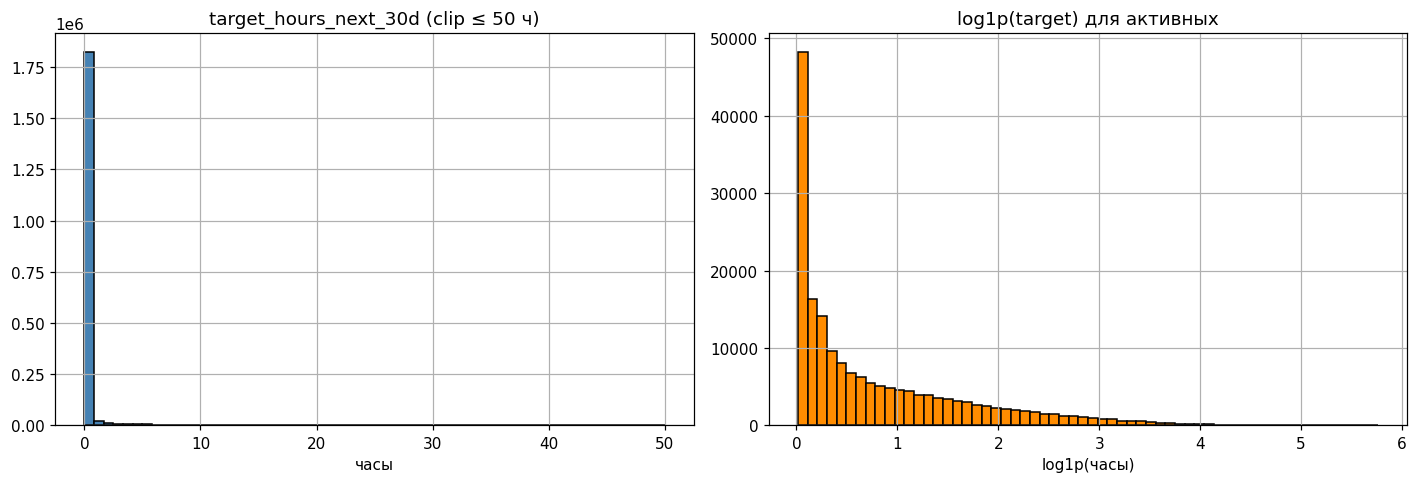

In [9]:
print("\n" + "=" * 80)
print("3. EDA — РАСПРЕДЕЛЕНИЕ ТАРГЕТА")
print("=" * 80)
print(df[TARGET].describe(percentiles=[0.5, 0.9, 0.99]).round(3).to_string())
print(f"Доля нулей: {(df[TARGET] == 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df[TARGET].clip(0, 50), bins=60, color="steelblue", edgecolor="black")
axes[0].set_title("target_hours_next_30d (clip ≤ 50 ч)")
axes[0].set_xlabel("часы")
pos = df.loc[df[TARGET] > 0, TARGET]
axes[1].hist(np.log1p(pos), bins=60, color="darkorange", edgecolor="black")
axes[1].set_title("log1p(target) для активных")
axes[1].set_xlabel("log1p(часы)")
save_fig("eda_target_distribution.png")

## 4. EDA — дрейф target и доли активных по неделям

Этот двух-осевой график из ноутбука по нейросети — самый компактный визуальный
индикатор `concept drift`:

- **Левая (оранжевая) ось** — средний `target` по snapshot-дате. Если ползёт —
  пользователи в среднем стали играть больше/меньше за тот же горизонт.
- **Правая (зелёная) ось** — доля пользователей с `target > 0` (т.е.
  «активность» — кто вообще вернулся).

Когда обе оси меняются согласованно — это масштабирующая нестабильность
(пропорция активных меняется). Когда расходятся — меняется и состав активных,
и сколько играют те, кто играет.

Под графиком — отдельная гистограмма количества пользователей в каждой
snapshot-дате (для контекста).


4. EDA — ДРЕЙФ TARGET И ДОЛИ АКТИВНЫХ ВО ВРЕМЕНИ
               n_users  target_mean  active_share
snapshot_date                                    
2025-12-01       94259        0.299         0.111
2025-12-08      108795        0.275         0.106
2025-12-15      131619        0.251         0.104
2025-12-22      135297        0.267         0.112
2025-12-29      141372        0.269         0.096
2026-01-05      143575        0.252         0.088
2026-01-12      131833        0.237         0.082
2026-01-19      130640        0.261         0.091
2026-01-26      121595        0.256         0.089
2026-02-02      107334        0.269         0.093
2026-02-09       99515        0.277         0.093
2026-02-16       91597        0.273         0.092
2026-02-23       84538        0.298         0.100
2026-03-02       83393        0.285         0.099
2026-03-09       80805        0.250         0.093
2026-03-16       78467        0.244         0.088
2026-03-23       72514        0.230         0.083


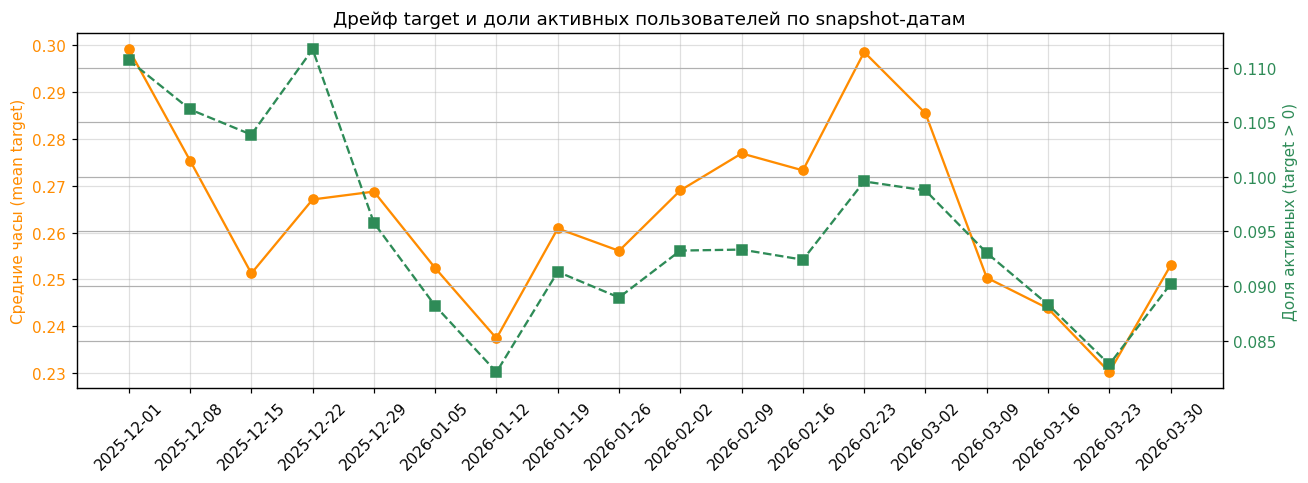

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_n_users.png


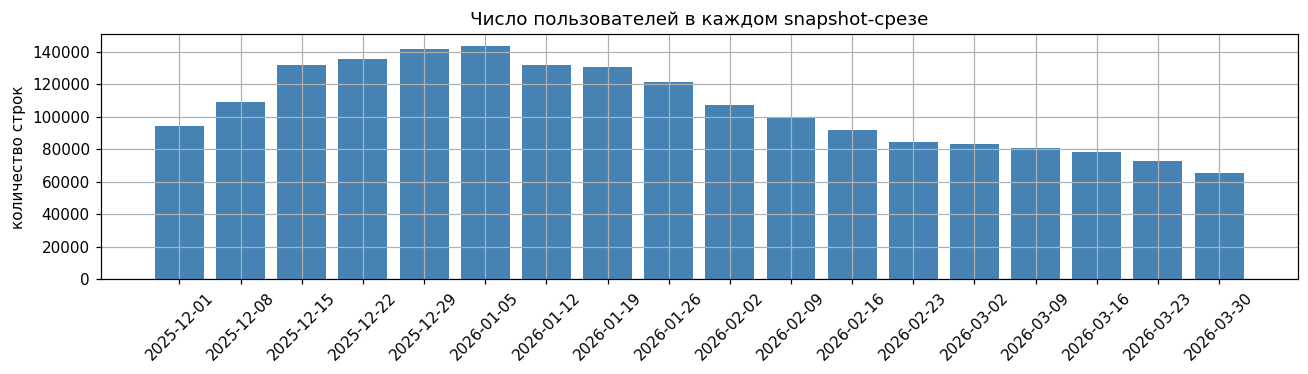

In [10]:
print("\n" + "=" * 80)
print("4. EDA — ДРЕЙФ TARGET И ДОЛИ АКТИВНЫХ ВО ВРЕМЕНИ")
print("=" * 80)
# График из nn_stability: на одной оси x = snapshot_date, на двух y осях —
# средний target и доля активных. Сразу видно concept drift по обоим показателям.
date_stats = df.groupby("snapshot_date").agg(
    n_users=("user_id", "size"),
    target_mean=(TARGET, "mean"),
    active_share=(TARGET, lambda x: (x > 0).mean()),
)
print(date_stats.round(3))
date_stats.to_csv(os.path.join(ART_DIR, "eda_date_stats.csv"))

labels = [d.strftime("%Y-%m-%d") for d in date_stats.index]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(labels, date_stats["target_mean"].values, "o-", color="darkorange", label="mean target")
ax.set_ylabel("Средние часы (mean target)", color="darkorange")
ax.tick_params(axis="y", labelcolor="darkorange")
ax.tick_params(axis="x", rotation=45)
ax2 = ax.twinx()
ax2.plot(labels, date_stats["active_share"].values, "s--", color="seagreen", label="share active")
ax2.set_ylabel("Доля активных (target > 0)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")
ax.set_title("Дрейф target и доли активных пользователей по snapshot-датам")
ax.grid(alpha=0.4)
save_fig("eda_target_and_active_drift.png")

# Дополнительно — число пользователей
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(labels, date_stats["n_users"], color="steelblue")
ax.set_title("Число пользователей в каждом snapshot-срезе")
ax.set_ylabel("количество строк")
ax.tick_params(axis="x", rotation=45)
save_fig("eda_n_users.png")

## 5. EDA — covariate drift по версиям и странам

Главный практический источник дрейфа в нашей задаче — **смена версии
приложения**. За 4 месяца датасета доминирующая версия меняется несколько
раз (выкаты новых билдов). Stackplot долей версий показывает это явно.

География (топ-5 стран) обычно стабильнее, но небольшой сдвиг по странам
тоже виден.

Эти факты явно отразятся в PSI (Часть 11) и adversarial validation
(Часть 12).


5. EDA — COVARIATE DRIFT (версии и страны)


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/eda_covariate_drift.png


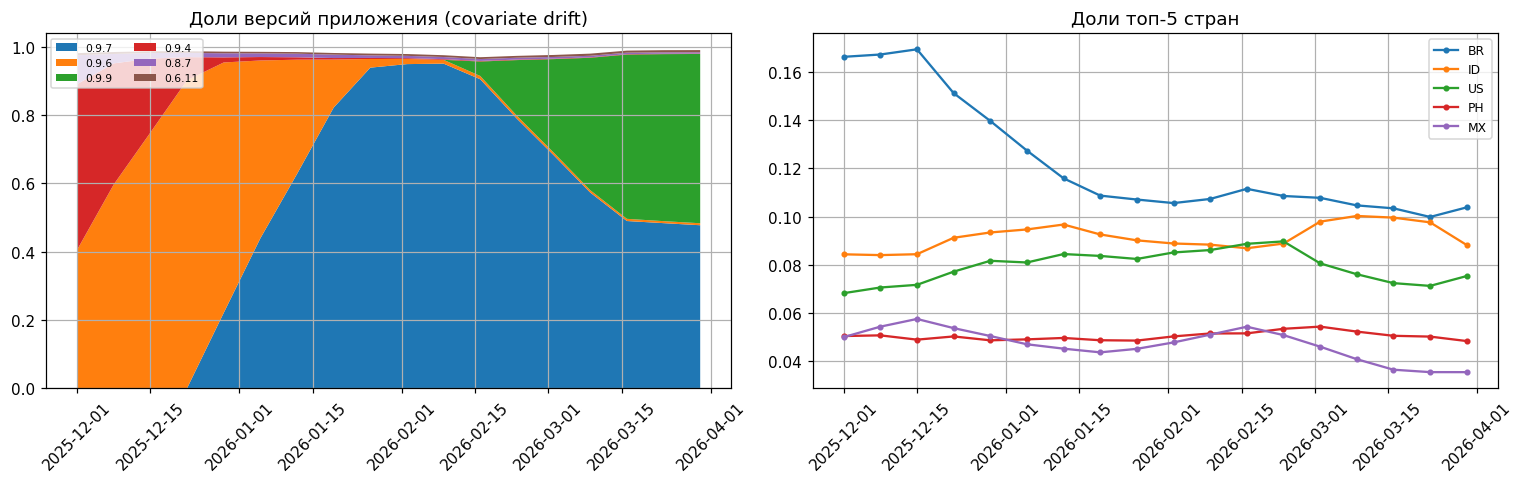

In [11]:
print("\n" + "=" * 80)
print("5. EDA — COVARIATE DRIFT (версии и страны)")
print("=" * 80)


def share_over_time(col, top_k=6):
    top = df[col].value_counts().head(top_k).index
    piv = df.groupby(["snapshot_date", col]).size().unstack(fill_value=0)
    piv = piv.div(piv.sum(axis=1), axis=0)
    return piv[top]


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sv = share_over_time("app_version_name", 6)
axes[0].stackplot(sv.index, sv.T.values, labels=sv.columns)
axes[0].set_title("Доли версий приложения (covariate drift)")
axes[0].legend(loc="upper left", fontsize=7, ncol=2)
axes[0].tick_params(axis="x", rotation=45)
sc = share_over_time("country_iso_code", 5)
for c in sc.columns:
    axes[1].plot(sc.index, sc[c], marker=".", label=c)
axes[1].set_title("Доли топ-5 стран")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)
save_fig("eda_covariate_drift.png")

## 6. Split train / val / test

Делим строго по `snapshot_date`. Конфигурация:

- **train** — первые 7 снэпшотов (`dates[0..6]`, 2025-12-01 → 2026-01-12);
- **val** — 4 снэпшота в зоне purge (2026-01-19 → 2026-02-09);
- **test** — 7 поздних снэпшотов (2026-02-16 → 2026-03-30).

**Что такое val в этом контексте.** Это переходная зона между train и
«чистым» test. Между `train_end` и этими датами проходит < 30 дней,
поэтому окна target частично пересекаются с train (target = next 30 days
после snapshot). Значит, метрики на val чуть оптимистично смещены —
о чём мы помним при интерпретации.

**Назначение val** — показывать на графиках Spearman / RMSE деградацию
сразу после train (val) и затем за зоной purge (test). Визуально видно
эффект «переходной зоны».

In [12]:
print("\n" + "=" * 80)
print("6. SPLIT TRAIN / VAL / TEST")
print("=" * 80)
# Train = первые 7 снэпшотов. Между ними и test ставим purge = 30 дней
# (= горизонту таргета), чтобы окна target не пересекались.
# Снэпшоты между train_end и test (4 шт.) обозначаем как "val" — это переходная
# зона, удобная для визуализации деградации. Метрики на ней слегка оптимистично
# смещены (target частично пересекается с train), и об этом будет пометка.
N_TRAIN_SNAPS = 6
train_end = pd.Timestamp(dates_all[N_TRAIN_SNAPS])
purge_threshold = train_end + pd.Timedelta(days=H)

train_dates = [pd.Timestamp(d) for d in dates_all[: N_TRAIN_SNAPS + 1]]
val_dates = [pd.Timestamp(d) for d in dates_all if train_end < pd.Timestamp(d) <= purge_threshold]
test_dates = [pd.Timestamp(d) for d in dates_all if pd.Timestamp(d) > purge_threshold]

print(f"train_end = {train_end.date()}  |  purge = {H} дней")
print(f"train ({len(train_dates)}): {[d.date() for d in train_dates]}")
print(f"val   ({len(val_dates)}): {[d.date() for d in val_dates]}  (зона purge)")
print(f"test  ({len(test_dates)}): {[d.date() for d in test_dates]}")


6. SPLIT TRAIN / VAL / TEST
train_end = 2026-01-12  |  purge = 30 дней
train (7): [datetime.date(2025, 12, 1), datetime.date(2025, 12, 8), datetime.date(2025, 12, 15), datetime.date(2025, 12, 22), datetime.date(2025, 12, 29), datetime.date(2026, 1, 5), datetime.date(2026, 1, 12)]
val   (4): [datetime.date(2026, 1, 19), datetime.date(2026, 1, 26), datetime.date(2026, 2, 2), datetime.date(2026, 2, 9)]  (зона purge)
test  (7): [datetime.date(2026, 2, 16), datetime.date(2026, 2, 23), datetime.date(2026, 3, 2), datetime.date(2026, 3, 9), datetime.date(2026, 3, 16), datetime.date(2026, 3, 23), datetime.date(2026, 3, 30)]


## Базовая конфигурация LightGBM (LGB_BASE)

Стандартный «kaggle-baseline»-набор параметров, описанный в нескольких
независимых источниках (например, [гайд Leonie Monigatti](https://www.leoniemonigatti.com/blog/lightgbm-hyperparameters.html)
и [официальная документация LightGBM](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html)):

- `learning_rate=0.05` — умеренный темп (kaggle-стандарт);
- `n_estimators=300` — лимит сверху;
- `num_leaves=63` (≈ 2⁶−1, эффективная глубина 6);
- `min_data_in_leaf=200` — защита от переобучения на 1.3 М строк
  (рекомендация: «сотни-тысячи для больших датасетов»);
- `feature_fraction=0.9`, `bagging_fraction=0.9, bagging_freq=1` — лёгкая
  стохастика (точное совпадение с гайдом).

Конфигурация не подобрана через grid search — это сознательный выбор:
baseline должен быть «разумным», а не «переоптимизированным», иначе
стабилизирующие приёмы сравнивались бы с искусственно сильной моделью.

In [13]:
# Базовая конфигурация LightGBM, единая для всех экспериментов.
# Значения соответствуют общепринятым «kaggle-baseline» рекомендациям:
# https://www.leoniemonigatti.com/blog/lightgbm-hyperparameters.html
LGB_BASE = dict(
    objective="regression", metric="rmse",
    learning_rate=0.05, n_estimators=300,
    num_leaves=63, min_data_in_leaf=200,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
cfg = FEATS["EXTENDED"]

## 7. Baseline — Ridge log static

Линейная модель с L2-регуляризацией (`alpha=3.0`) на EXTENDED-наборе,
с `log1p`-преобразованием числовых признаков и таргета.

Это — отправная точка для всего блока «линейная модель»: 5 вариантов
deep-dive (Часть 13) тренируются именно поверх этой схемы.

На графиках — две кривые (val и test) одной моделью, чтобы было видно
переход качества через purge-зону.


7. BASELINE — RIDGE log (static, EXTENDED)


  [val] 2026-01-19  Spearman=+0.348  RMSE=2.021  n_train=886,750  (9.0s)


  [val] 2026-01-26  Spearman=+0.343  RMSE=2.190  n_train=886,750  (2.0s)


  [val] 2026-02-02  Spearman=+0.358  RMSE=2.189  n_train=886,750  (2.0s)


  [val] 2026-02-09  Spearman=+0.361  RMSE=2.182  n_train=886,750  (1.9s)


...

  [test] 2026-03-09  Spearman=+0.359  RMSE=1.811  n_train=886,750  (1.9s)


  [test] 2026-03-16  Spearman=+0.351  RMSE=1.927  n_train=886,750  (2.0s)


  [test] 2026-03-23  Spearman=+0.345  RMSE=1.905  n_train=886,750  (1.9s)


  [test] 2026-03-30  Spearman=+0.358  RMSE=2.111  n_train=886,750  (1.9s)



[Ridge] заняло 29.0s

Ridge сводка по val: {'model': 'Ridge val', 'Spearman_mean': 0.3525518633867285, 'Spearman_std': 0.007285746997149482, 'stability': 0.9927669511666682, 'slope': 0.005282484652491204, 'R2_mean': 0.19521323268069868, 'RMSE_mean': 2.1456548344815283, 'MAE_mean': 0.2692008472204859}
Ridge сводка по test: {'model': 'Ridge test', 'Spearman_mean': 0.3616164448878097, 'Spearman_std': 0.011317797275038134, 'stability': 0.988808861758852, 'slope': -0.003954311987030093, 'R2_mean': 0.20012559213235198, 'RMSE_mean': 2.0290903390408053, 'MAE_mean': 0.26593730782928005}
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_ridge_spearman.png


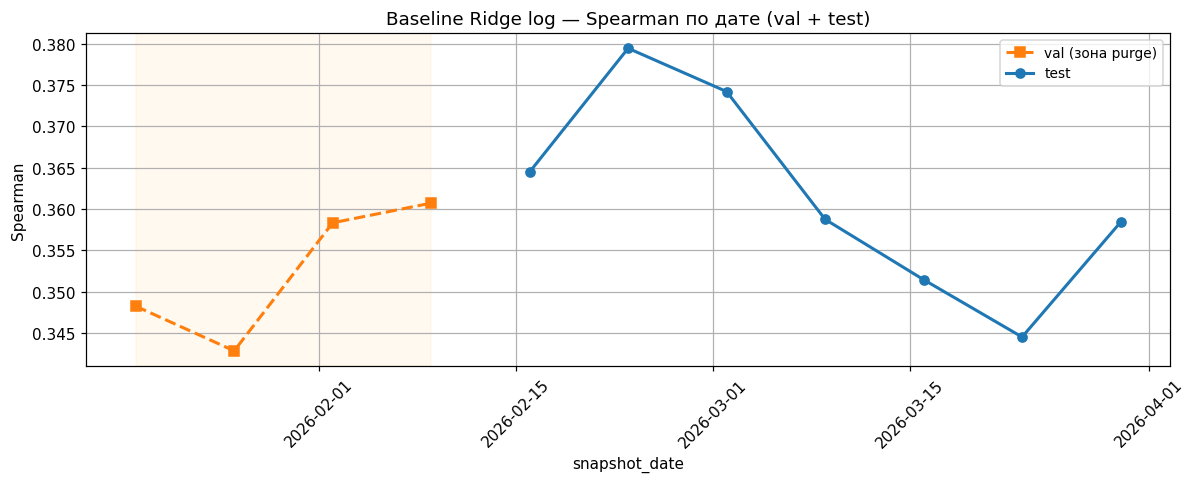

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_ridge_rmse.png


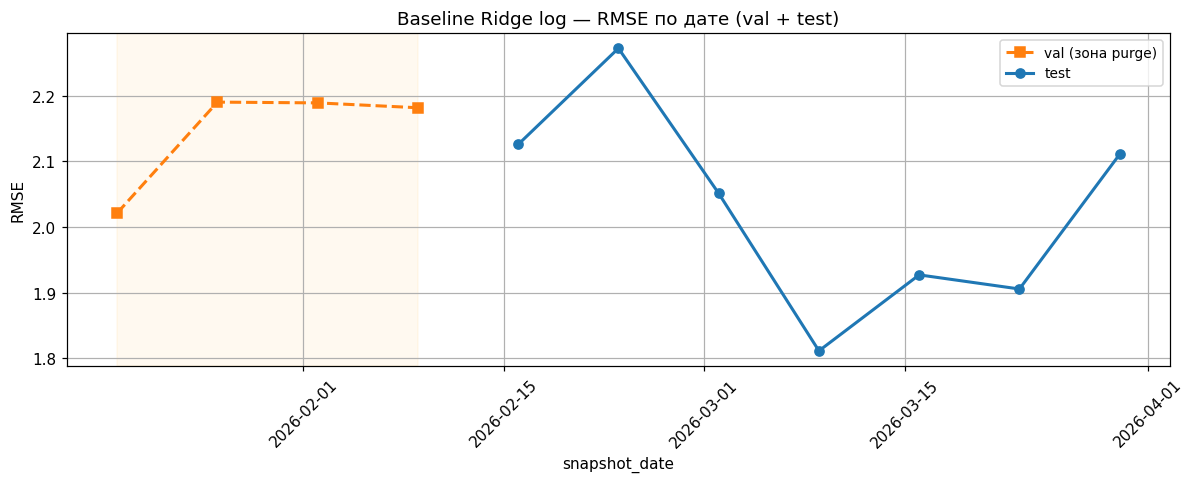

In [14]:
print("\n" + "=" * 80)
print("7. BASELINE — RIDGE log (static, EXTENDED)")
print("=" * 80)
t0 = time.time()
base_ridge = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="ridge", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, use_log_num=True, alpha=3.0, verbose=True,
)
print(f"\n[Ridge] заняло {time.time()-t0:.1f}s")
base_ridge.to_csv(os.path.join(ART_DIR, "baseline_ridge.csv"), index=False)
print("\nRidge сводка по val:", stability_row("Ridge val", base_ridge, "val"))
print("Ridge сводка по test:", stability_row("Ridge test", base_ridge, "test"))

plot_val_test_curve(base_ridge, "Spearman",
                    "Baseline Ridge log — Spearman по дате (val + test)")
save_fig("baseline_ridge_spearman.png")
plot_val_test_curve(base_ridge, "RMSE",
                    "Baseline Ridge log — RMSE по дате (val + test)")
save_fig("baseline_ridge_rmse.png")

## 8. Baseline — LightGBM static (log target)

Главная точка отсчёта всего ноутбука. Конфигурация `LGB_BASE`,
`log_target=True`. Все эксперименты LightGBM сравниваются с этой кривой
в Части 14.

Снова — две кривые (val и test) на одной фигуре.


8. BASELINE — LightGBM (static, EXTENDED, log target)


  [val] 2026-01-19  Spearman=+0.375  RMSE=1.903  n_train=886,750  (8.6s)


  [val] 2026-01-26  Spearman=+0.364  RMSE=2.030  n_train=886,750  (0.8s)


  [val] 2026-02-02  Spearman=+0.376  RMSE=2.015  n_train=886,750  (0.7s)


  [val] 2026-02-09  Spearman=+0.377  RMSE=2.034  n_train=886,750  (0.7s)


...

  [test] 2026-03-09  Spearman=+0.372  RMSE=1.696  n_train=886,750  (0.7s)


  [test] 2026-03-16  Spearman=+0.366  RMSE=1.818  n_train=886,750  (0.7s)


  [test] 2026-03-23  Spearman=+0.358  RMSE=1.803  n_train=886,750  (0.6s)


  [test] 2026-03-30  Spearman=+0.375  RMSE=2.019  n_train=886,750  (0.6s)



[LGBM] заняло 15.8s

LGBM сводка по val: {'model': 'LGBM val', 'Spearman_mean': 0.37295794353875505, 'Spearman_std': 0.005254516085418919, 'stability': 0.994772949535327, 'slope': 0.001756755663698616, 'R2_mean': 0.30357037967865486, 'RMSE_mean': 1.9953960400738127, 'MAE_mean': 0.2510893312624651}
LGBM сводка по test: {'model': 'LGBM test', 'Spearman_mean': 0.37448790518296876, 'Spearman_std': 0.010362503887724785, 'stability': 0.989743776270545, 'slope': -0.0031160665087713525, 'R2_mean': 0.2862332301371489, 'RMSE_mean': 1.9167981297759518, 'MAE_mean': 0.24928788078735084}
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_lgbm_spearman.png


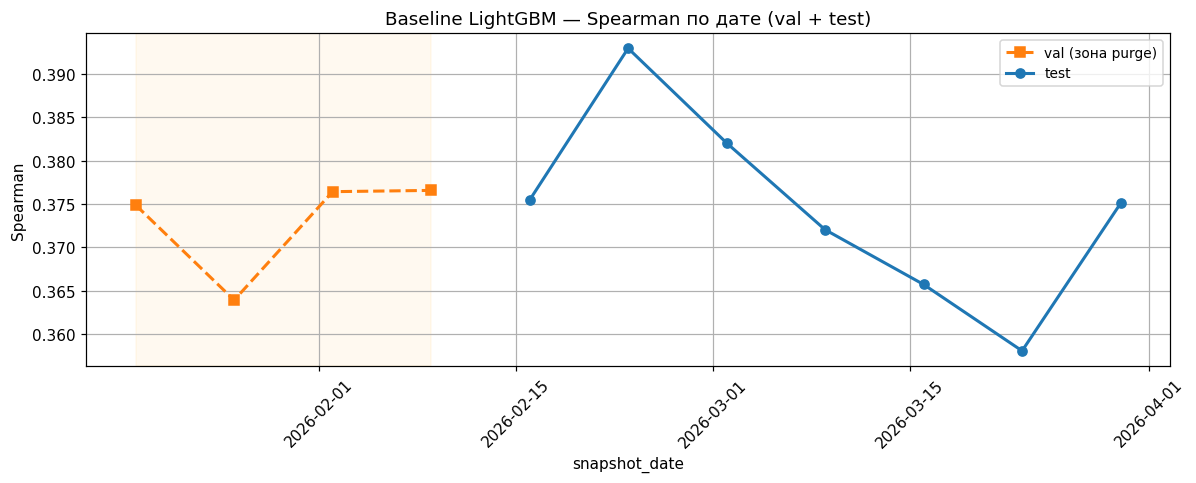

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_lgbm_rmse.png


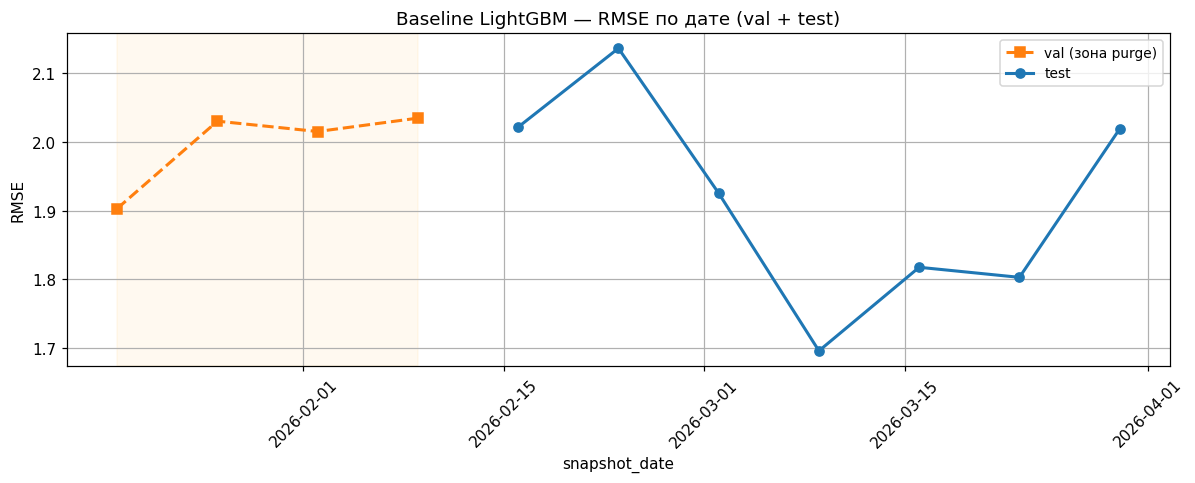

In [15]:
print("\n" + "=" * 80)
print("8. BASELINE — LightGBM (static, EXTENDED, log target)")
print("=" * 80)
t0 = time.time()
base_lgbm = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="lgbm", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, lgb_params=LGB_BASE, verbose=True,
)
print(f"\n[LGBM] заняло {time.time()-t0:.1f}s")
base_lgbm.to_csv(os.path.join(ART_DIR, "baseline_lgbm.csv"), index=False)
print("\nLGBM сводка по val:", stability_row("LGBM val", base_lgbm, "val"))
print("LGBM сводка по test:", stability_row("LGBM test", base_lgbm, "test"))

plot_val_test_curve(base_lgbm, "Spearman",
                    "Baseline LightGBM — Spearman по дате (val + test)")
save_fig("baseline_lgbm_spearman.png")
plot_val_test_curve(base_lgbm, "RMSE",
                    "Baseline LightGBM — RMSE по дате (val + test)")
save_fig("baseline_lgbm_rmse.png")

## 9. Baseline — MLP (sklearn)

Маленькая нейросеть `(64, 32)` с ReLU + Adam, log-таргет, early stopping.
Препроцессинг — тот же что у Ridge (one-hot + frequency + StandardScaler).
Обучаем один раз на train (благодаря кэшу в `temporal_eval`), потом просто
предсказываем для каждой val/test даты.

**Скорость.** На 880 тыс. строк один fit занимает ~30-90 секунд. Static-кэш
делает baseline MLP практически таким же быстрым, как Ridge.

**Не PyTorch.** На Python 3.14 + macOS у PyTorch-варианта были deadlock'и
после серии операций (MPS / OpenMP). sklearn проще и надёжнее. Для
курсовой эта простота приоритетнее. Углублённое PyTorch-исследование MLP
с кастомными loss'ами и эмбеддингами категорий — в отдельном файле
`nn_stability.ipynb`.


9. BASELINE — MLP (sklearn, static, EXTENDED)


  [val] 2026-01-19  Spearman=+0.364  RMSE=1.943  n_train=886,750  (14.3s)


  [val] 2026-01-26  Spearman=+0.352  RMSE=2.038  n_train=886,750  (2.0s)


  [val] 2026-02-02  Spearman=+0.366  RMSE=2.035  n_train=886,750  (2.0s)


  [val] 2026-02-09  Spearman=+0.367  RMSE=2.060  n_train=886,750  (2.0s)


...

  [test] 2026-03-09  Spearman=+0.361  RMSE=1.727  n_train=886,750  (1.9s)


  [test] 2026-03-16  Spearman=+0.353  RMSE=1.864  n_train=886,750  (1.9s)


  [test] 2026-03-23  Spearman=+0.346  RMSE=1.836  n_train=886,750  (1.9s)


  [test] 2026-03-30  Spearman=+0.361  RMSE=2.049  n_train=886,750  (1.9s)



[MLP] заняло 34.1s

MLP сводка по val: {'model': 'MLP val', 'Spearman_mean': 0.3622144815918924, 'Spearman_std': 0.005816815242578409, 'stability': 0.9942168244212785, 'slope': 0.0023679436801012435, 'R2_mean': 0.2867240890560988, 'RMSE_mean': 2.0189255092062965, 'MAE_mean': 0.24967185220692517}
MLP сводка по test: {'model': 'MLP test', 'Spearman_mean': 0.3645542226904583, 'Spearman_std': 0.012672341768843581, 'stability': 0.987486236913799, 'slope': -0.004651907891381365, 'R2_mean': 0.2588434775925474, 'RMSE_mean': 1.953208764624511, 'MAE_mean': 0.24888235117202936}
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_mlp_spearman.png


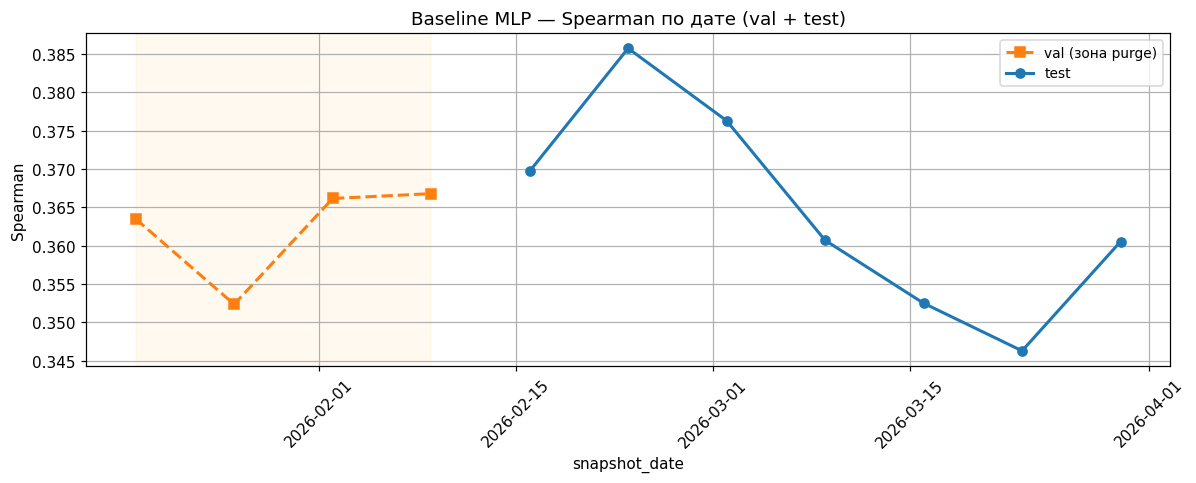

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_mlp_rmse.png


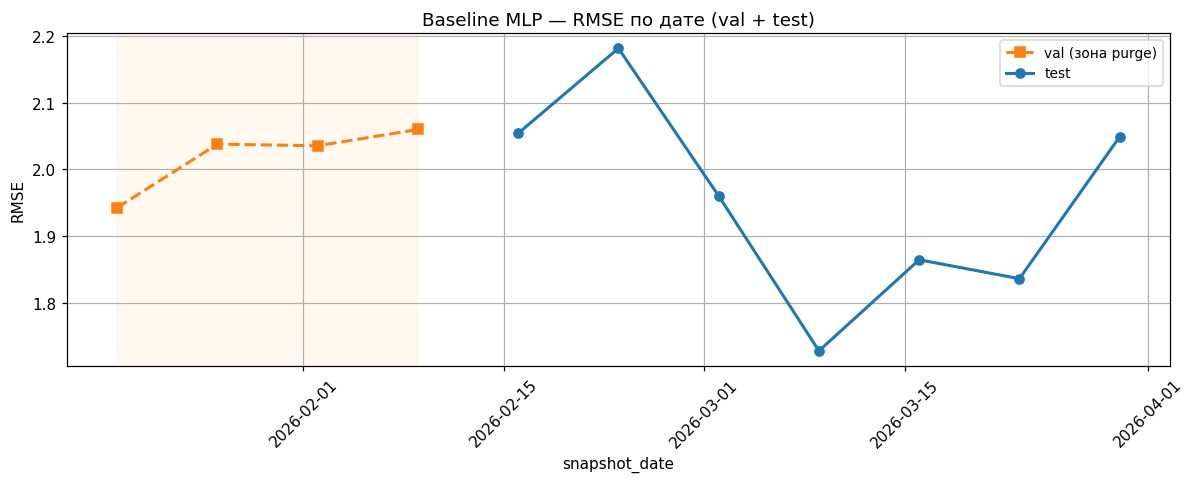

In [16]:
print("\n" + "=" * 80)
print("9. BASELINE — MLP (sklearn, static, EXTENDED)")
print("=" * 80)
t0 = time.time()
base_mlp = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"],
    model_kind="mlp", train_end=train_end, mode="static",
    val_dates=val_dates, test_dates=test_dates,
    mlp_hidden=(64, 32), mlp_epochs=20, verbose=True,
)
print(f"\n[MLP] заняло {time.time()-t0:.1f}s")
base_mlp.to_csv(os.path.join(ART_DIR, "baseline_mlp.csv"), index=False)
print("\nMLP сводка по val:", stability_row("MLP val", base_mlp, "val"))
print("MLP сводка по test:", stability_row("MLP test", base_mlp, "test"))

plot_val_test_curve(base_mlp, "Spearman",
                    "Baseline MLP — Spearman по дате (val + test)")
save_fig("baseline_mlp_spearman.png")
plot_val_test_curve(base_mlp, "RMSE",
                    "Baseline MLP — RMSE по дате (val + test)")
save_fig("baseline_mlp_rmse.png")

## 10. Сравнение трёх baseline на одних графиках

Кладём кривые Ridge / LightGBM / MLP на одни оси по Spearman и RMSE.
Видно сразу:
- какая модель лучше «из коробки» по среднему качеству;
- у какой круче падение от val к test (большая деградация);
- какая ровнее во времени.

В сводной таблице — `Spearman_mean`, `Spearman_std`, `stability` для val и
test отдельно.


10. СРАВНЕНИЕ ТРЁХ BASELINES (Ridge / LightGBM / MLP)
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baselines_overlay_spearman.png


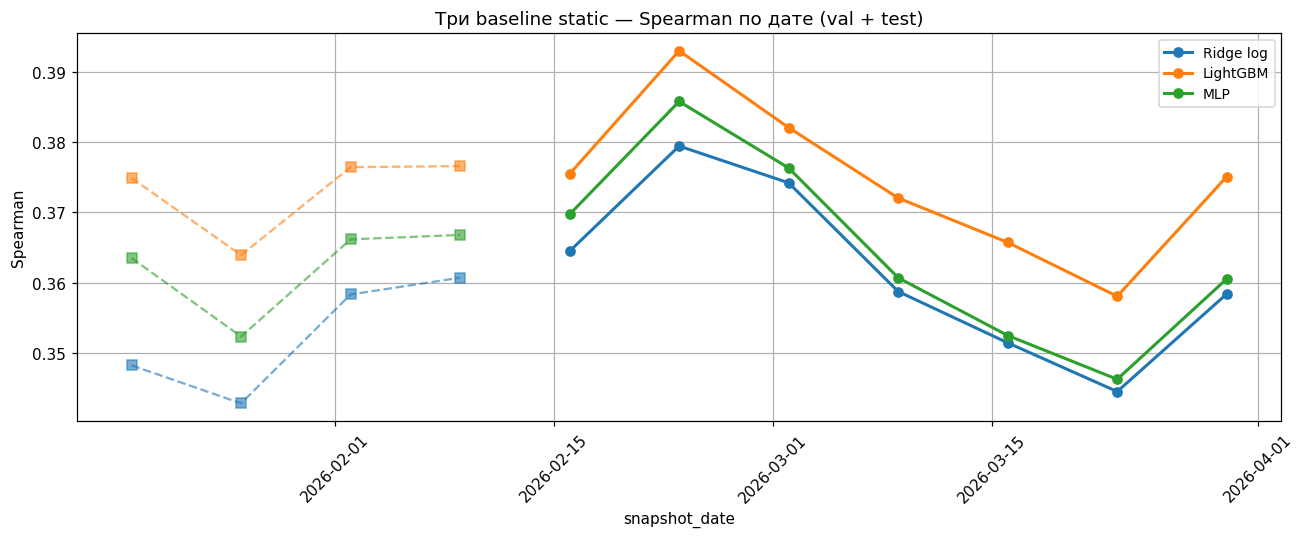

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baselines_overlay_rmse.png


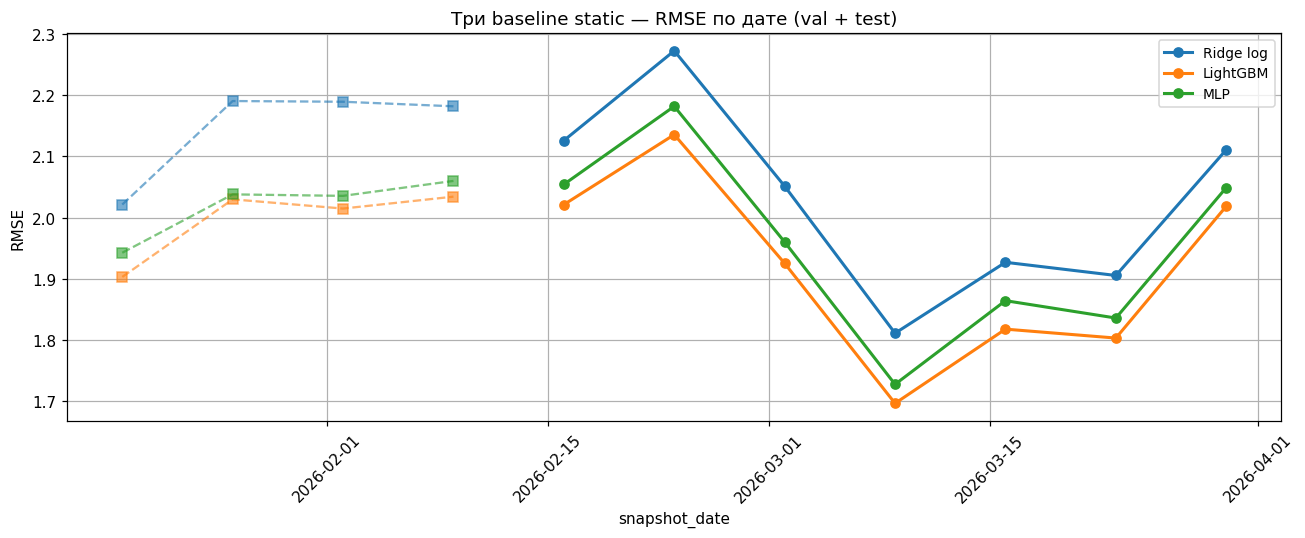


Сводка baselines (val + test):
           model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
 Ridge log (val)         0.3526        0.0073     0.9928  0.0053   0.1952     2.1457    0.2692
Ridge log (test)         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659
  LightGBM (val)         0.3730        0.0053     0.9948  0.0018   0.3036     1.9954    0.2511
 LightGBM (test)         0.3745        0.0104     0.9897 -0.0031   0.2862     1.9168    0.2493
       MLP (val)         0.3622        0.0058     0.9942  0.0024   0.2867     2.0189    0.2497
      MLP (test)         0.3646        0.0127     0.9875 -0.0047   0.2588     1.9532    0.2489


In [17]:
print("\n" + "=" * 80)
print("10. СРАВНЕНИЕ ТРЁХ BASELINES (Ridge / LightGBM / MLP)")
print("=" * 80)
baselines = {"Ridge log": base_ridge, "LightGBM": base_lgbm, "MLP": base_mlp}
plot_three_curves(baselines, "Spearman",
                  "Три baseline static — Spearman по дате (val + test)")
save_fig("baselines_overlay_spearman.png")
plot_three_curves(baselines, "RMSE",
                  "Три baseline static — RMSE по дате (val + test)")
save_fig("baselines_overlay_rmse.png")

rows = []
for name, c in baselines.items():
    rows.append(stability_row(f"{name} (val)", c, "val"))
    rows.append(stability_row(f"{name} (test)", c, "test"))
baselines_summary = pd.DataFrame([r for r in rows if r is not None])
print("\nСводка baselines (val + test):")
print(baselines_summary.round(4).to_string(index=False))
baselines_summary.to_csv(os.path.join(ART_DIR, "baselines_summary.csv"), index=False)

## 11. PSI — Population Stability Index

Стандартная метрика дрейфа: разница распределений признака между train и
тест-снэпшотом. Эмпирические пороги: <0.10 — стабильно, 0.10–0.25 —
умеренный сдвиг, >0.25 — сильный сдвиг.

Считаем PSI отдельно для числовых (`psi_num`) и для двух высококардинальных
категорий (`psi_cat`). `was_nan`-флаги в PSI не идут — для бинарных
индикаторов индекс неинформативен.


11. ДИАГНОСТИКА ДРЕЙФА — PSI


Топ-15 признаков по среднему PSI:
app_version_name                                  6.694
country_iso_code                                  0.182
days_since_first_seen                             0.066
ml_snap_kills_last_minute_mean_30d                0.054
ml_init_days_since_install_last_30d               0.040
ml_init_session_cnt_last_30d                      0.039
ml_snap_itemtoken_balance_mean_30d                0.035
ml_init_global_death_count_last_30d               0.033
ml_snap_itemtoken_revenue_last_minute_sum_30d     0.032
ml_snap_health_mean_30d                           0.030
ml_snap_health_ratio_min_30d                      0.030
ml_snap_damage_mean_30d                           0.029
ml_snap_itemtoken_ad_reward_calculate_mean_30d    0.029
ml_snap_player_dps_mean_30d                       0.029
ml_snap_money_balance_mean_30d                    0.029
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/psi_top5.png


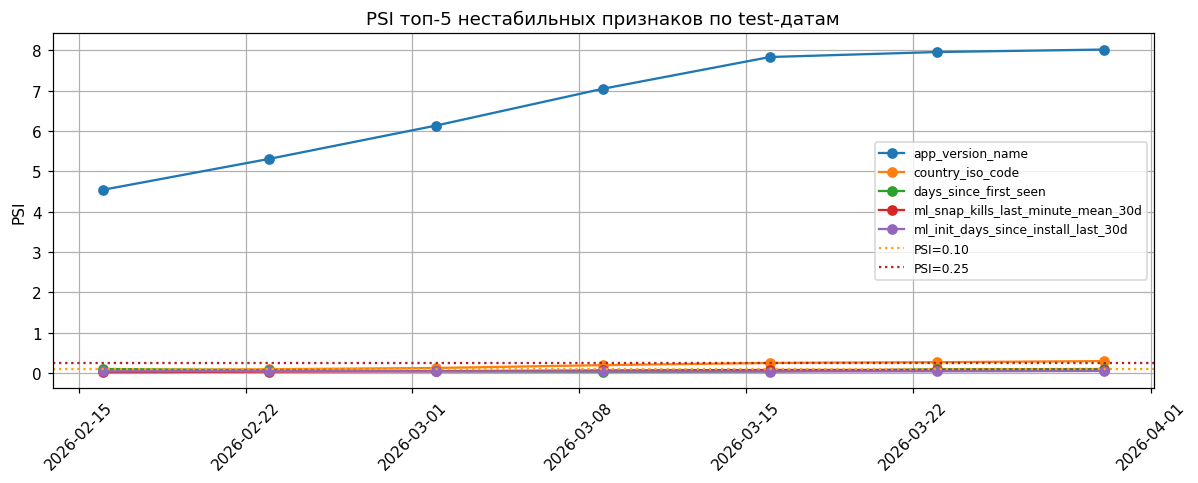

In [18]:
print("\n" + "=" * 80)
print("11. ДИАГНОСТИКА ДРЕЙФА — PSI")
print("=" * 80)


def psi_num(ref, cur, bins=10):
    qs = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3:
        return 0.0
    r = np.histogram(ref, qs)[0] / max(len(ref), 1)
    c = np.histogram(cur, qs)[0] / max(len(cur), 1)
    r = np.clip(r, 1e-4, None)
    c = np.clip(c, 1e-4, None)
    return float(np.sum((c - r) * np.log(c / r)))


def psi_cat(ref, cur):
    r = ref.value_counts(normalize=True)
    c = cur.value_counts(normalize=True)
    cats = set(r.index) | set(c.index)
    rr = np.clip(np.array([r.get(k, 0) for k in cats]), 1e-4, None)
    cc = np.clip(np.array([c.get(k, 0) for k in cats]), 1e-4, None)
    return float(np.sum((cc - rr) * np.log(cc / rr)))


ref_df = df[df["snapshot_date"] <= train_end]
PSI_NUM_FEATS = BASELINE_NUM + ML_EXT_NUM
psi_num_tab = pd.DataFrame(
    {f: [psi_num(ref_df[f].values, df[df["snapshot_date"] == d][f].values) for d in test_dates]
     for f in PSI_NUM_FEATS},
    index=[d.date() for d in test_dates],
)
psi_cat_tab = pd.DataFrame(
    {f: [psi_cat(ref_df[f], df[df["snapshot_date"] == d][f]) for d in test_dates]
     for f in CAT_HIGH},
    index=[d.date() for d in test_dates],
)
mean_psi = pd.concat([psi_num_tab.mean(), psi_cat_tab.mean()]).sort_values(ascending=False)
print("Топ-15 признаков по среднему PSI:")
print(mean_psi.head(15).round(3).to_string())
mean_psi.to_csv(os.path.join(ART_DIR, "psi_mean.csv"))

fig, ax = plt.subplots(figsize=(11, 4.5))
for f in mean_psi.head(5).index:
    src = psi_cat_tab if f in CAT_HIGH else psi_num_tab
    ax.plot(src.index, src[f], marker="o", label=f)
ax.axhline(0.10, ls=":", c="orange", label="PSI=0.10")
ax.axhline(0.25, ls=":", c="firebrick", label="PSI=0.25")
ax.set_title("PSI топ-5 нестабильных признаков по test-датам")
ax.set_ylabel("PSI")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
save_fig("psi_top5.png")

## 12. Adversarial validation + важность признаков

Тренируем бинарный LightGBM-классификатор `is_test` (1 = строка из test,
0 = из train) **только на признаках без таргета**. ROC-AUC ≈ 0.5 — train и
test неотличимы, дрейфа нет; AUC > 0.9 — сильный дрейф.

**Важно:** топ-10 признаков по `feature_importance` — **это не AUC**, а
абсолютные значения выигрыша по loss (gain), которые могут быть в миллионах
на больших датасетах. Они показывают, **какая колонка** доминирует в
способности классификатора различать train и test.

На графике топ-15 показаны в долях от общей суммы gain — сразу видно,
концентрирован ли дрейф в одной колонке или размазан.

Объединение `mean_psi > 0.10` и `top adversarial` даёт список `UNSTABLE` —
кандидаты на удаление в эксперименте `drop_unstable`.


12. ADVERSARIAL VALIDATION (train vs test)


Adversarial AUC: 0.9734  (это бинарная AUC, в [0,1])
Топ-10 признаков (gain — НЕ AUC, абсолютные значения выигрыша по loss):
app_version_name                          2199233.0
days_since_first_seen                      187602.0
country_iso_code                            56444.0
ml_init_days_since_install_last_30d         39474.0
playtime_hours_14d                          36339.0
events_count_7d                             32119.0
ml_init_avg_playtime_lifetime_last_30d       8813.0
ml_init_hours_since_last_game_last_30d       8356.0
events_count_30d                             7362.0
ml_snap_kills_last_minute_mean_30d           6109.0
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/adversarial_top_importance.png


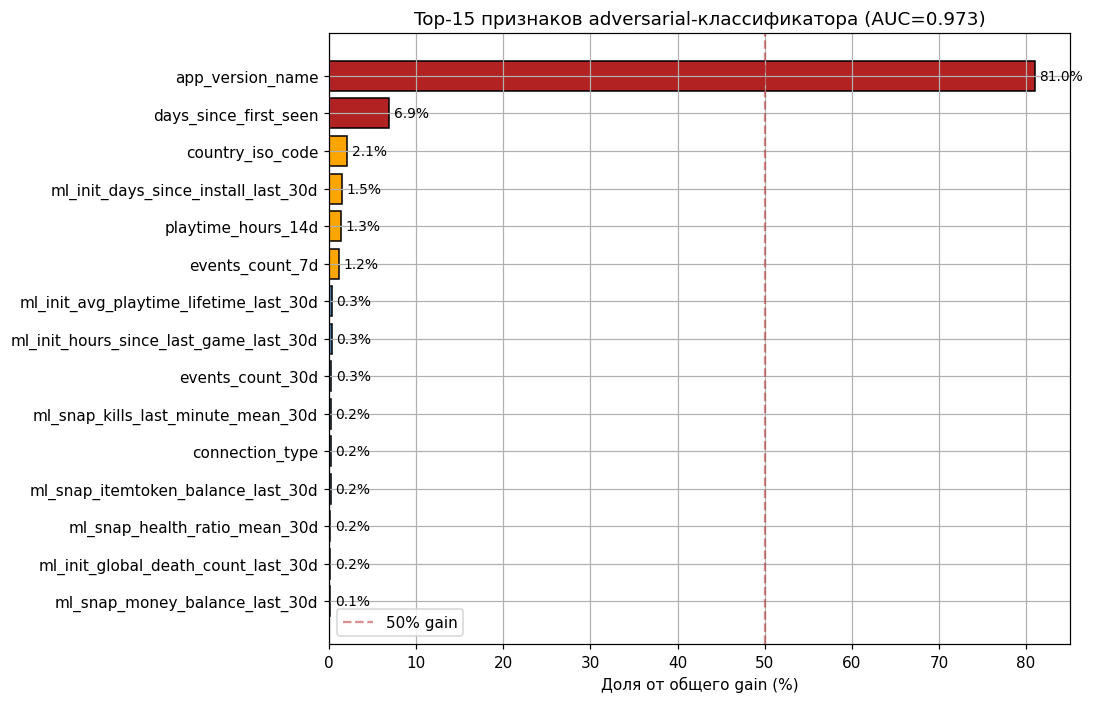


Кандидаты на удаление (PSI > 0.10 ∪ top adversarial): 8
  app_version_name
  country_iso_code
  days_since_first_seen
  events_count_7d
  ml_init_avg_playtime_lifetime_last_30d
  ml_init_days_since_install_last_30d
  ml_init_hours_since_last_game_last_30d
  playtime_hours_14d


In [19]:
print("\n" + "=" * 80)
print("12. ADVERSARIAL VALIDATION (train vs test)")
print("=" * 80)
SAMPLE_PER_SIDE = 200_000
tr_sample = ref_df.sample(n=min(SAMPLE_PER_SIDE, len(ref_df)), random_state=RANDOM_STATE)
te_df_all = df[df["snapshot_date"].isin([np.datetime64(d) for d in test_dates])]
te_sample = te_df_all.sample(n=min(SAMPLE_PER_SIDE, len(te_df_all)), random_state=RANDOM_STATE)

adv_feats = BASELINE_NUM + ML_EXT_NUM + WASNAN + CAT_LOW + CAT_HIGH
adv_X = pd.concat([tr_sample[adv_feats], te_sample[adv_feats]], axis=0).reset_index(drop=True)
for c in CAT_LOW + CAT_HIGH:
    adv_X[c] = adv_X[c].astype("category")
adv_y = np.concatenate([np.zeros(len(tr_sample)), np.ones(len(te_sample))])
rng = np.random.default_rng(RANDOM_STATE)
order = rng.permutation(len(adv_X))
adv_X = adv_X.iloc[order].reset_index(drop=True)
adv_y = adv_y[order]
sp = int(0.7 * len(adv_X))

adv_clf = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
adv_clf.fit(adv_X.iloc[:sp], adv_y[:sp],
            eval_set=[(adv_X.iloc[sp:], adv_y[sp:])],
            categorical_feature=CAT_LOW + CAT_HIGH,
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
adv_auc = roc_auc_score(adv_y[sp:], adv_clf.predict_proba(adv_X.iloc[sp:])[:, 1])
print(f"Adversarial AUC: {adv_auc:.4f}  (это бинарная AUC, в [0,1])")

adv_imp = pd.Series(adv_clf.booster_.feature_importance(importance_type="gain"),
                    index=adv_clf.feature_name_).sort_values(ascending=False)
top_adv = adv_imp.head(10)
print("Топ-10 признаков (gain — НЕ AUC, абсолютные значения выигрыша по loss):")
print(top_adv.round(0).to_string())
adv_imp.to_csv(os.path.join(ART_DIR, "adversarial_importance.csv"))

# График топ-15 в долях от суммы (наглядно показывает доминирование одной фичи)
top15 = adv_imp.head(15)
share = (top15 / adv_imp.sum()) * 100
fig, ax = plt.subplots(figsize=(10, 6.5))
colors = ["firebrick" if v > 5 else ("orange" if v > 1 else "steelblue") for v in share]
ax.barh(top15.index[::-1], share.values[::-1], color=colors[::-1], edgecolor="black")
for i, v in enumerate(share.values[::-1]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.axvline(50, color="firebrick", ls="--", alpha=0.5, label="50% gain")
ax.set_xlabel("Доля от общего gain (%)")
ax.set_title(f"Top-15 признаков adversarial-классификатора (AUC={adv_auc:.3f})")
ax.legend()
save_fig("adversarial_top_importance.png")

UNSTABLE = sorted(set(mean_psi[mean_psi > 0.10].index[:20]) | set(top_adv.index[:8]))
print(f"\nКандидаты на удаление (PSI > 0.10 ∪ top adversarial): {len(UNSTABLE)}")
for u in UNSTABLE:
    print(f"  {u}")


def stable_subset(cfg_in):
    return dict(
        num=[c for c in cfg_in["num"] if c not in UNSTABLE],
        low=[c for c in cfg_in["low"] if c not in UNSTABLE],
        high=[c for c in cfg_in["high"] if c not in UNSTABLE],
    )


stable_cfg = stable_subset(cfg)

## 13. Линейная модель — углублённое исследование

Пять вариантов, каждый — один шаг в сторону стабилизации:

1. **Linear raw** — без log-преобразований и без log-таргета;
2. **Linear log** — signed log1p числовых + log1p(target);
3. **Ridge log** — добавляем L2 (это наш baseline из Части 7);
4. **Ridge log + drop_unstable** — выкидываем признаки из `UNSTABLE`;
5. **Ridge log + sliding (42d)** — rolling retrain.

Все сравниваются на одних графиках. Сводная таблица показывает Spearman,
stability и slope (наклон деградации).


13. ЛИНЕЙНАЯ МОДЕЛЬ — DEEP DIVE (5 вариантов)

--- Linear raw ---



--- Linear log ---



--- Ridge log + drop_unstable ---



--- Ridge log + sliding 42d ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/linear_compare_spearman.png


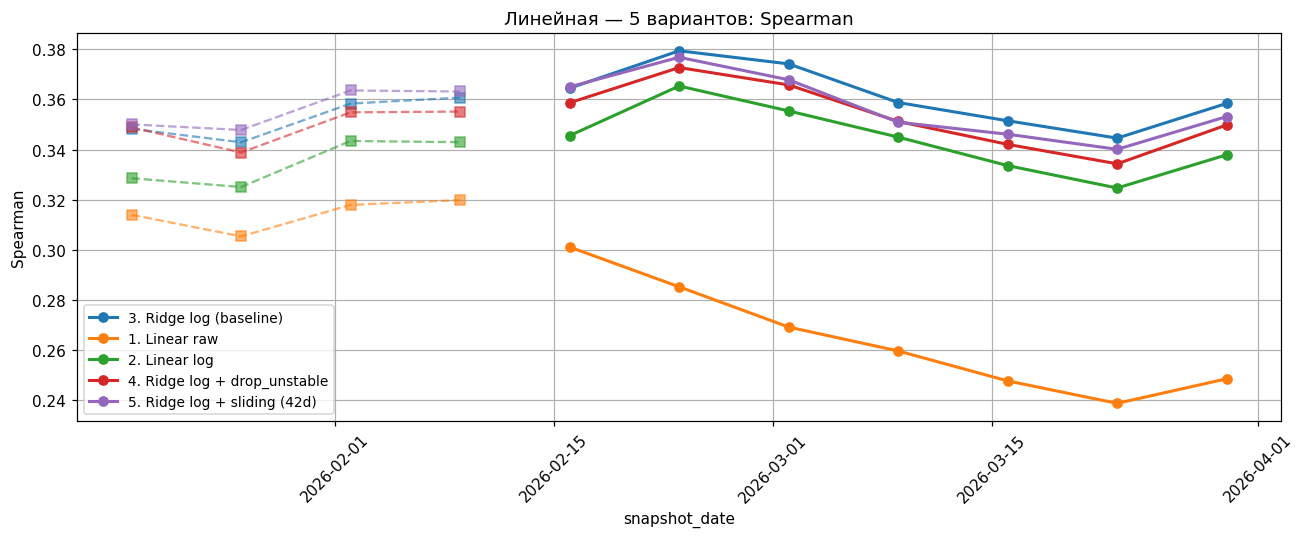

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/linear_compare_rmse.png


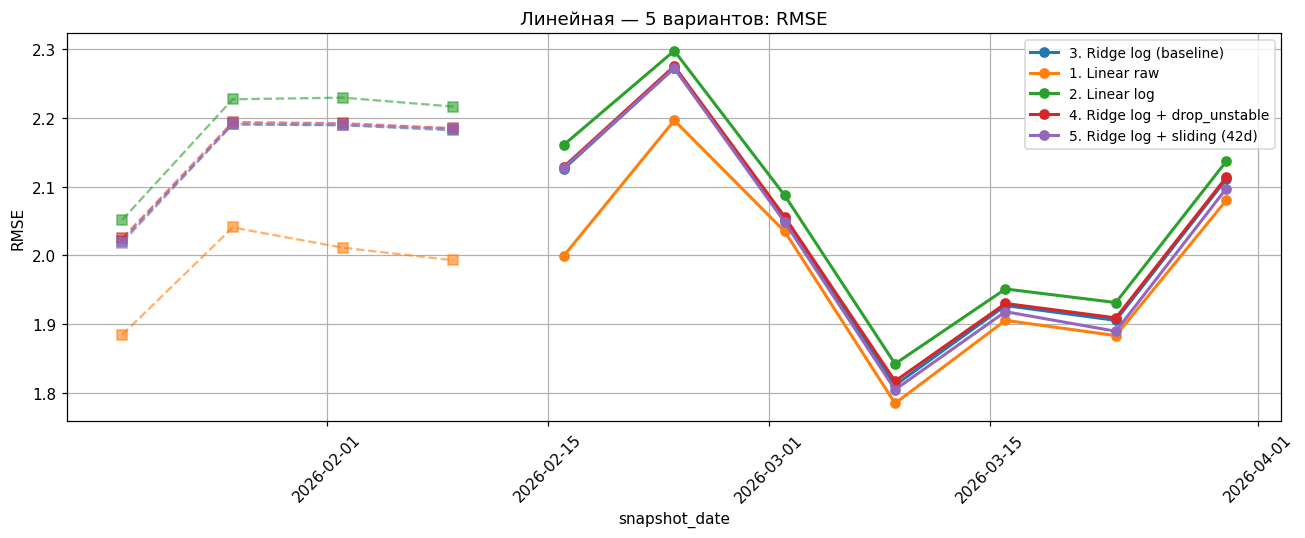


Линейная — сводка по TEST:
                       model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
     3. Ridge log (baseline)         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659
               1. Linear raw         0.2642        0.0208     0.9796 -0.0097   0.2346     1.9834    0.3738
               2. Linear log         0.3439        0.0126     0.9876 -0.0045   0.1770     2.0581    0.2757
4. Ridge log + drop_unstable         0.3535        0.0123     0.9878 -0.0045   0.1972     2.0328    0.2686
5. Ridge log + sliding (42d)         0.3571        0.0121     0.9880 -0.0047   0.2056     2.0225    0.2644


In [ ]:
print("\n" + "=" * 80)
print("13. ЛИНЕЙНАЯ МОДЕЛЬ — DEEP DIVE (5 вариантов)")
print("=" * 80)
linear_curves = {"3. Ridge log (baseline)": base_ridge}

# Linear raw
print("\n--- Linear raw ---")
linear_curves["1. Linear raw"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "linear", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=False, use_log_num=False,
)

# Linear log
print("\n--- Linear log ---")
linear_curves["2. Linear log"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "linear", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, use_log_num=True,
)

# # Ridge log + drop_unstable
# print("\n--- Ridge log + drop_unstable ---")
# linear_curves["4. Ridge log + drop_unstable"] = temporal_eval(
#     df, stable_cfg["num"], stable_cfg["low"], stable_cfg["high"], "ridge", train_end, "static",
#     val_dates=val_dates, test_dates=test_dates,
#     log_target=True, use_log_num=True, alpha=3.0,
# )




plot_three_curves(linear_curves, "Spearman", "Линейная — 5 вариантов: Spearman")
save_fig("linear_compare_spearman.png")
plot_three_curves(linear_curves, "RMSE", "Линейная — 5 вариантов: RMSE")
save_fig("linear_compare_rmse.png")

linear_summary = pd.DataFrame([stability_row(n, c, "test") for n, c in linear_curves.items() if c is not None])
print("\nЛинейная — сводка по TEST:")
print(linear_summary.round(4).to_string(index=False))
linear_summary.to_csv(os.path.join(ART_DIR, "linear_summary.csv"), index=False)

## 14. LightGBM — углублённое исследование

Семь экспериментов поверх baseline:

1. **LGBM no-log** — нужно ли вообще log-таргет;
2. **LGBM regularized** — сильнее регуляризация (меньше листьев, L1/L2);
3. **LGBM drop_unstable** — выкидываем нестабильные признаки;
4. **LGBM huber** — robust loss;
5. **LGBM quantile-50** — предсказываем медиану (внимание: высокий Spearman
   может быть артефактом ties из-за 90 % нулей);
6. **LGBM two-stage hurdle** — `P(active) × E[hours|active]`, идея
   из 90 % нулей в таргете;
7. **LGBM sliding (42d)** — rolling retrain.

Каждый получает per-exp график с заливкой улучшение/ухудшение.


14. LightGBM — DEEP DIVE (9 экспериментов)

--- Эксп. 1: LGBM no-log ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_no_log.png


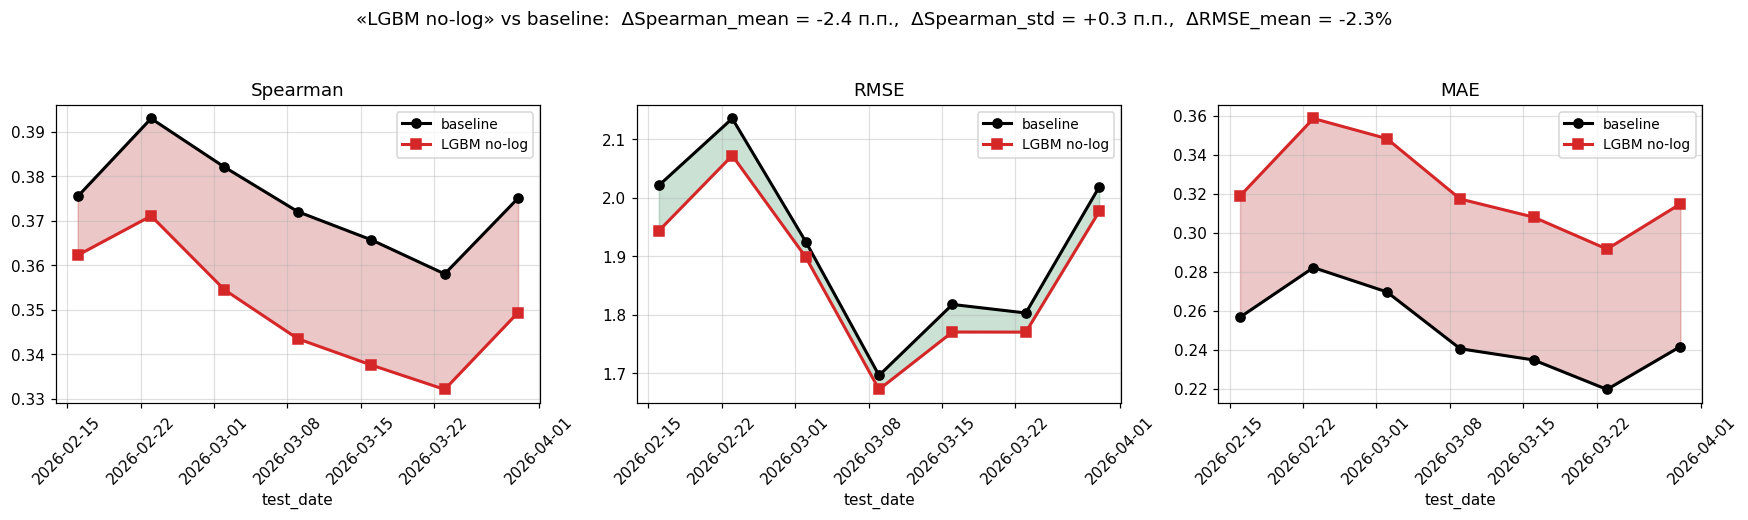


--- Эксп. 2: LGBM regularized ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_regularized.png


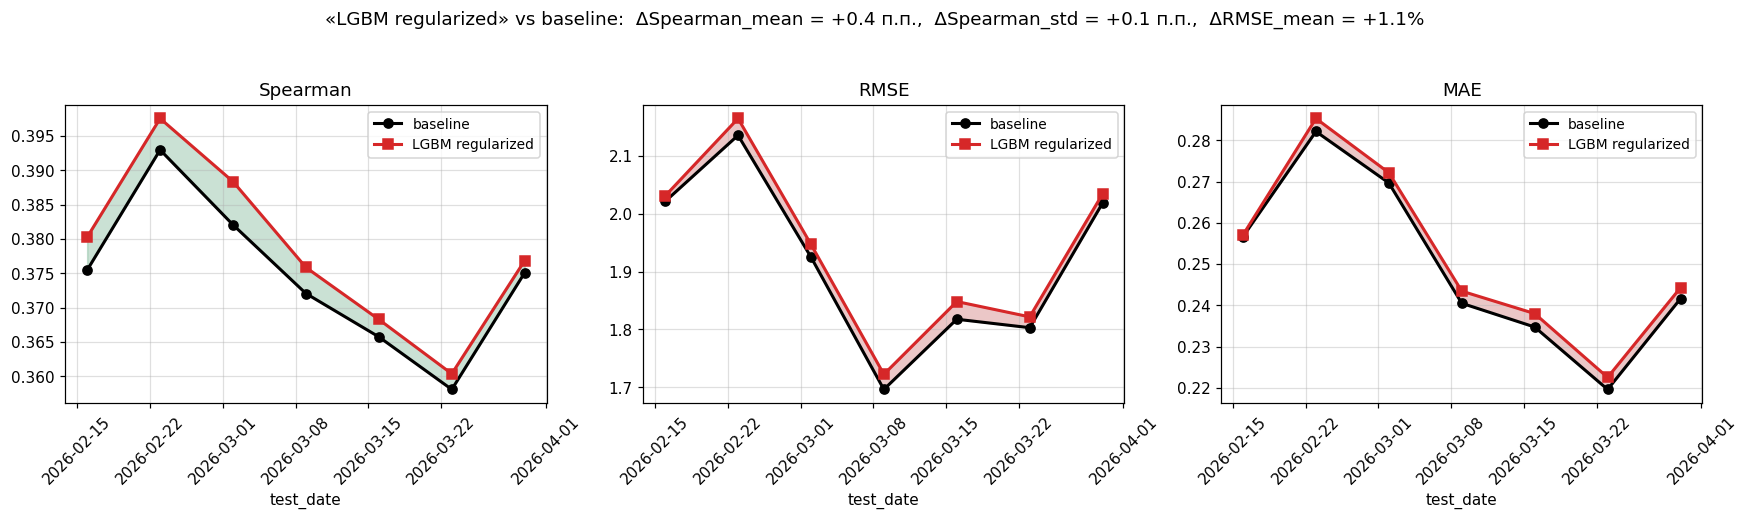


--- Эксп. 3: LGBM drop_unstable ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_drop_unstable.png


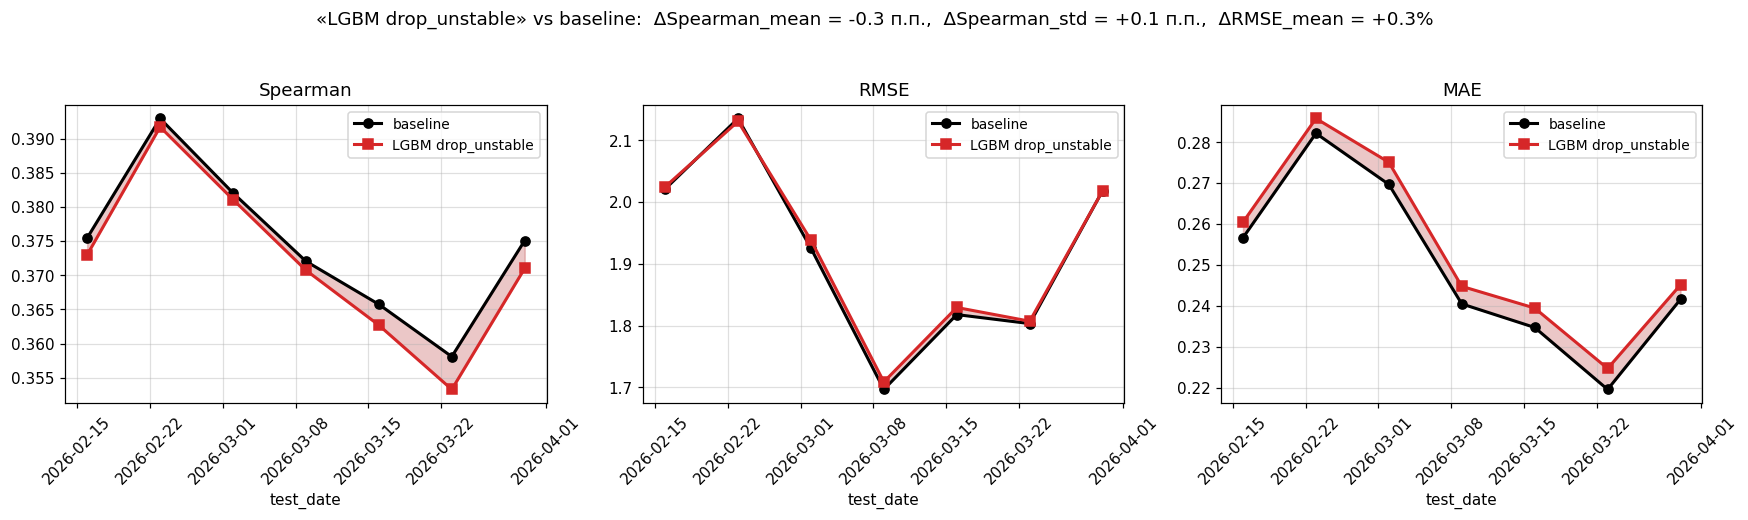


--- Эксп. 4: LGBM huber ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_huber.png


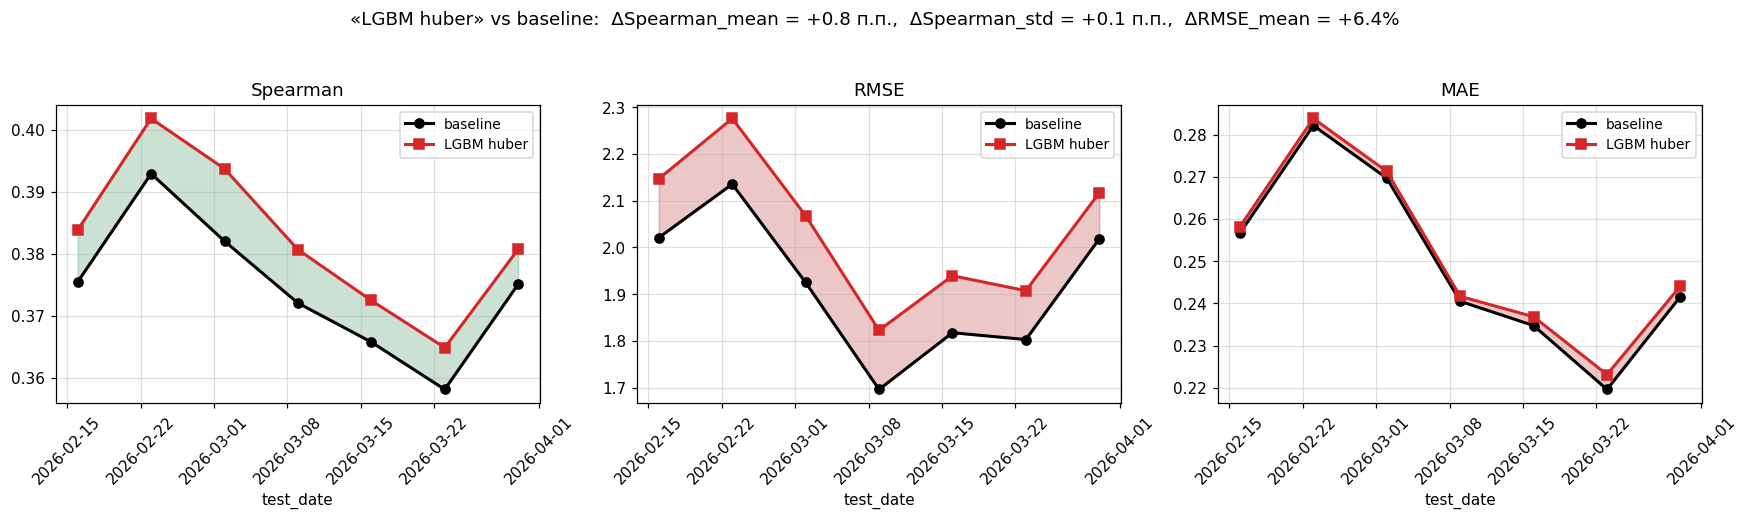


--- Эксп. 5: LGBM quantile-50 ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_quantile.png


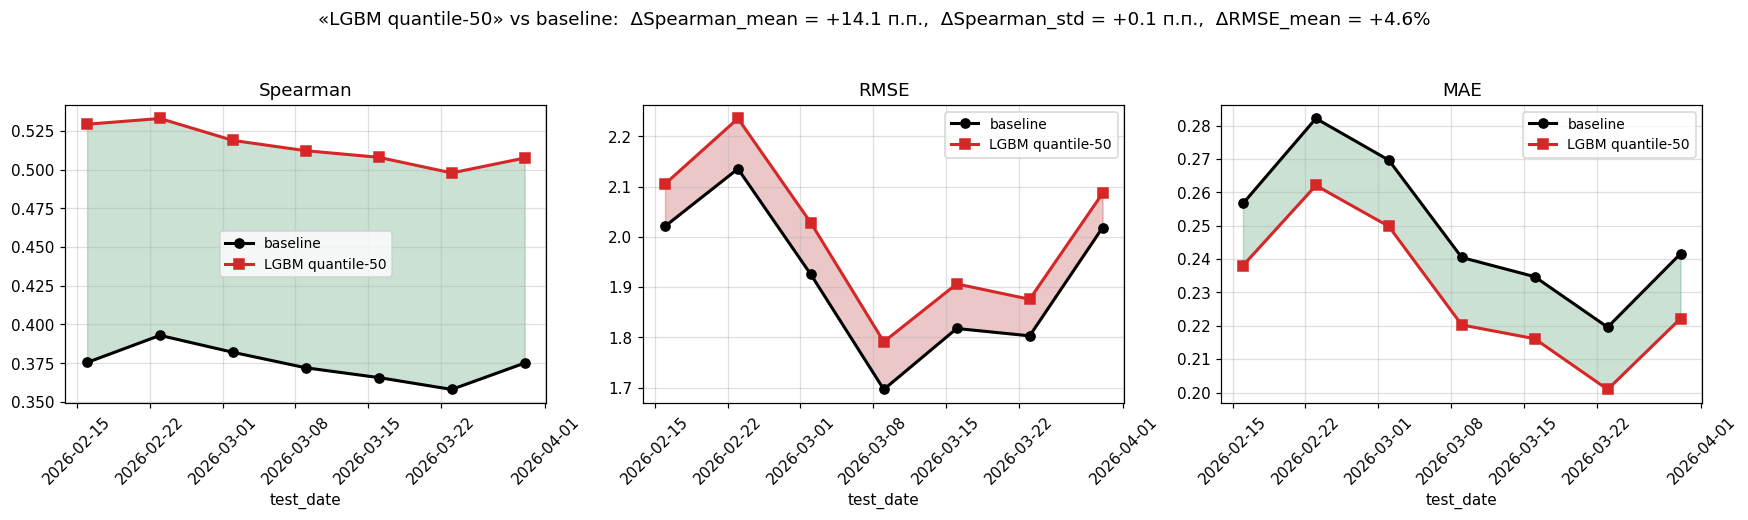


--- Эксп. 6: LGBM two-stage hurdle ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_two_stage.png


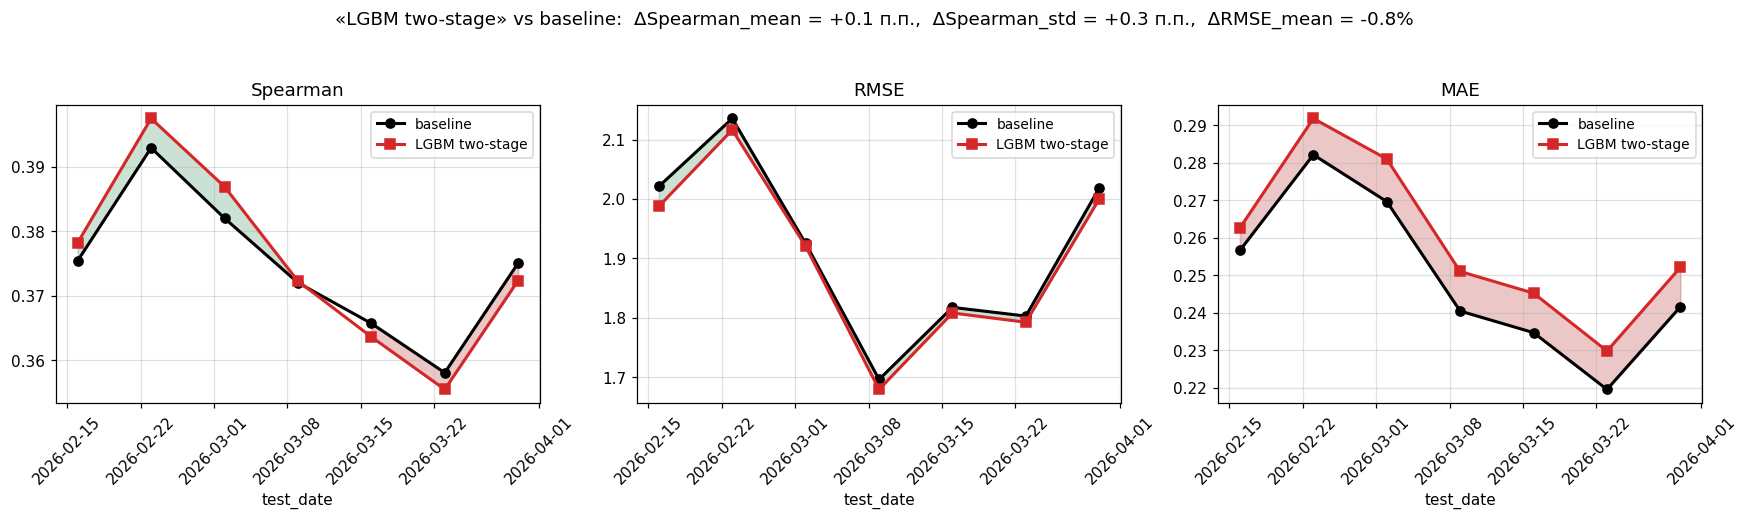


--- Эксп. 7: LGBM sliding 42d ---


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/exp_lgbm_sliding_42.png


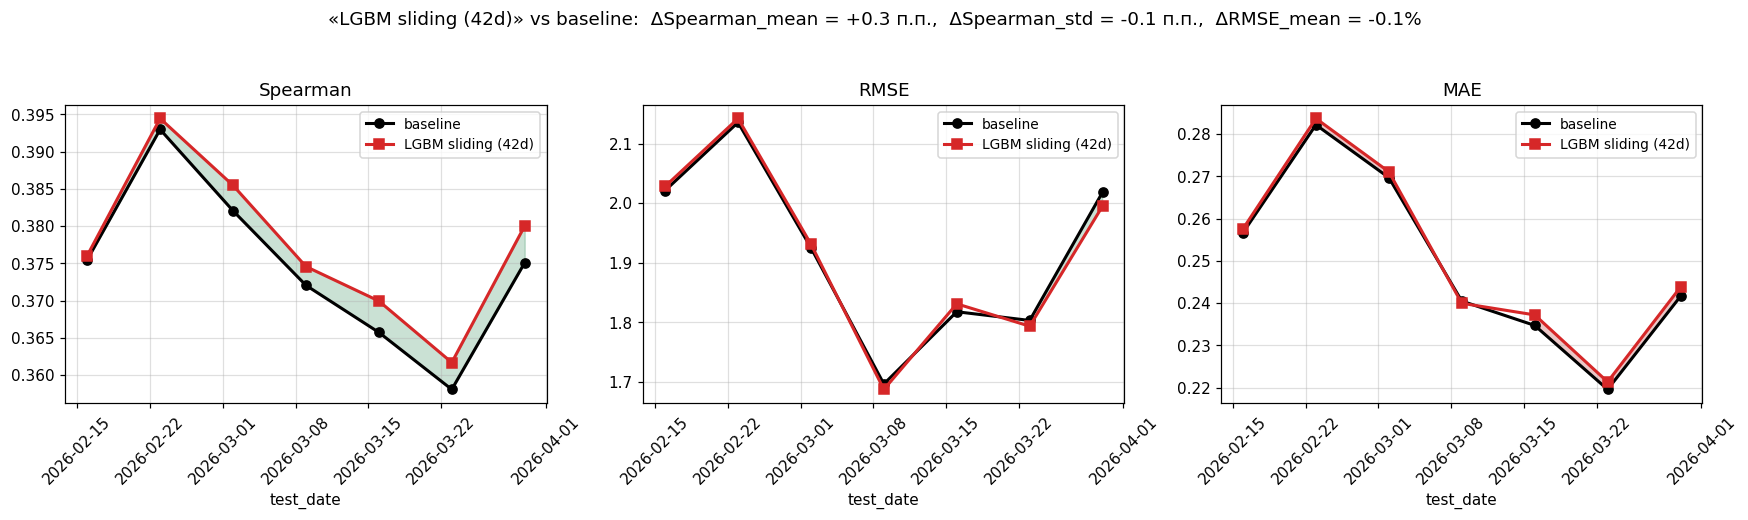


LightGBM — сводка по TEST:
                    model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
0. baseline (static, log)         0.3745        0.0104     0.9897 -0.0031   0.2862     1.9168    0.2493
           1. LGBM no-log         0.3501        0.0127     0.9875 -0.0048   0.3187     1.8721    0.3226
      2. LGBM regularized         0.3782        0.0114     0.9888 -0.0037   0.2699     1.9385    0.2518
    3. LGBM drop_unstable         0.3719        0.0114     0.9887 -0.0036   0.2819     1.9224    0.2537
            4. LGBM huber         0.3826        0.0115     0.9886 -0.0037   0.1918     2.0397    0.2513
      5. LGBM quantile-50         0.5152        0.0117     0.9885 -0.0052   0.2196     2.0042    0.2299
        6. LGBM two-stage         0.3752        0.0130     0.9872 -0.0045   0.2980     1.9008    0.2591
    7. LGBM sliding (42d)         0.3774        0.0098     0.9903 -0.0025   0.2874     1.9155    0.2507


In [21]:
print("\n" + "=" * 80)
print("14. LightGBM — DEEP DIVE (9 экспериментов)")
print("=" * 80)
lgbm_curves = {"0. baseline (static, log)": base_lgbm}

# Эксперимент 1: без log
print("\n--- Эксп. 1: LGBM no-log ---")
lgbm_curves["1. LGBM no-log"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=False, lgb_params=LGB_BASE,
)
plot_exp_vs_baseline("LGBM no-log", lgbm_curves["1. LGBM no-log"], base_lgbm,
                     save_name="exp_lgbm_no_log.png")

# Эксперимент 2: regularized
print("\n--- Эксп. 2: LGBM regularized ---")
LGB_REG = dict(LGB_BASE)
LGB_REG.update(num_leaves=31, min_data_in_leaf=500, reg_alpha=1.0, reg_lambda=5.0,
               feature_fraction=0.7, bagging_fraction=0.7,
               n_estimators=600, learning_rate=0.03)
lgbm_curves["2. LGBM regularized"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, lgb_params=LGB_REG,
)
plot_exp_vs_baseline("LGBM regularized", lgbm_curves["2. LGBM regularized"], base_lgbm,
                     save_name="exp_lgbm_regularized.png")

# Эксперимент 3: drop_unstable
print("\n--- Эксп. 3: LGBM drop_unstable ---")
lgbm_curves["3. LGBM drop_unstable"] = temporal_eval(
    df, stable_cfg["num"], stable_cfg["low"], stable_cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=True, lgb_params=LGB_BASE,
)
plot_exp_vs_baseline("LGBM drop_unstable", lgbm_curves["3. LGBM drop_unstable"], base_lgbm,
                     save_name="exp_lgbm_drop_unstable.png")

# Эксперимент 4: huber
print("\n--- Эксп. 4: LGBM huber ---")
LGB_HUBER = dict(LGB_BASE); LGB_HUBER.update(objective="huber", alpha=0.9, metric="rmse")
lgbm_curves["4. LGBM huber"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=False, lgb_params=LGB_HUBER,
)
plot_exp_vs_baseline("LGBM huber", lgbm_curves["4. LGBM huber"], base_lgbm,
                     save_name="exp_lgbm_huber.png")

# Эксперимент 5: quantile median
print("\n--- Эксп. 5: LGBM quantile-50 ---")
LGB_QUANT = dict(LGB_BASE); LGB_QUANT.update(objective="quantile", alpha=0.5, metric="rmse")
lgbm_curves["5. LGBM quantile-50"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "static",
    val_dates=val_dates, test_dates=test_dates,
    log_target=False, lgb_params=LGB_QUANT,
)
plot_exp_vs_baseline("LGBM quantile-50", lgbm_curves["5. LGBM quantile-50"], base_lgbm,
                     save_name="exp_lgbm_quantile.png")

# Эксперимент 6: two-stage hurdle (отдельный код — две модели на дату)
print("\n--- Эксп. 6: LGBM two-stage hurdle ---")
two_stage_rows = []
for split_name, dates_list in [("val", val_dates), ("test", test_dates)]:
    for td in dates_list:
        tr = df[df["snapshot_date"] <= train_end]
        te = df[df["snapshot_date"] == td]
        if len(tr) < 2000 or len(te) < 200:
            continue
        y_tr = tr[TARGET].astype(np.float32).values
        y_te = te[TARGET].astype(np.float32).values
        feat_cols = cfg["num"] + cfg["low"] + cfg["high"]
        X_tr = tr[feat_cols].copy()
        X_te = te[feat_cols].copy()
        for c in cfg["low"] + cfg["high"]:
            X_tr[c] = X_tr[c].astype("category")
            X_te[c] = X_te[c].astype("category")
        # Stage 1
        clf_p = dict(LGB_BASE); clf_p.update(objective="binary", metric="auc")
        clf = lgb.LGBMClassifier(**clf_p)
        clf.fit(X_tr, (y_tr > 0).astype(np.int8), categorical_feature=cfg["low"] + cfg["high"])
        p_active = clf.predict_proba(X_te)[:, 1]
        # Stage 2 — на активных
        am = y_tr > 0
        reg = lgb.LGBMRegressor(**LGB_BASE)
        reg.fit(X_tr[am], np.log1p(np.clip(y_tr[am], 0, None)),
                categorical_feature=cfg["low"] + cfg["high"])
        e_hours = np.expm1(np.clip(reg.predict(X_te), None, LOG_CAP))
        p = np.clip(p_active * e_hours, 0, CAP)
        p = np.nan_to_num(p, nan=0.0, posinf=CAP, neginf=0.0)
        row = {"test_date": pd.Timestamp(td), "split": split_name, **metrics(y_te, p)}
        two_stage_rows.append(row)
lgbm_curves["6. LGBM two-stage"] = pd.DataFrame(two_stage_rows)
plot_exp_vs_baseline("LGBM two-stage", lgbm_curves["6. LGBM two-stage"], base_lgbm,
                     save_name="exp_lgbm_two_stage.png")

# Эксперимент 7: sliding 42d
print("\n--- Эксп. 7: LGBM sliding 42d ---")
lgbm_curves["7. LGBM sliding (42d)"] = temporal_eval(
    df, cfg["num"], cfg["low"], cfg["high"], "lgbm", train_end, "sliding",
    train_win_days=42, val_dates=val_dates, test_dates=test_dates,
    log_target=True, lgb_params=LGB_BASE,
)
plot_exp_vs_baseline("LGBM sliding (42d)", lgbm_curves["7. LGBM sliding (42d)"], base_lgbm,
                     save_name="exp_lgbm_sliding_42.png")

lgbm_summary = pd.DataFrame([stability_row(n, c, "test") for n, c in lgbm_curves.items() if c is not None])
print("\nLightGBM — сводка по TEST:")
print(lgbm_summary.round(4).to_string(index=False))
lgbm_summary.to_csv(os.path.join(ART_DIR, "lgbm_summary.csv"), index=False)

## 14b. MLP mini deep-dive — 5 экспериментов

Поскольку LightGBM получил подробный deep-dive (Часть 14), для полноты картины
добавляем мини-исследование MLP — 5 экспериментов, выполнимых на `sklearn.MLPRegressor`.

**Какие из 10 экспериментов nn_stability перенесены:**

| # | Метод | sklearn? | Включён |
|---|---|---|---|
| 1 | no-log target | ✅ | ✓ |
| 2 | regularized (alpha + arch) | ✅ | ✓ |
| 3 | drop_unstable | ✅ | ✓ |
| 4 | Huber loss | ❌ (только MSE) | — |
| 5 | log1p target | ✅ (есть в baseline) | — |
| 6 | sliding retrain | ✅ | ✓ (W=70d) |
| 7 | seed-ансамбль | (опущено — экономия времени) | — |
| 8 | input noise | ❌ (нет hook) | — |
| 9 | two-stage hurdle | ✅ | ✓ |
| 10 | combo | (включён частично через regularized + drop_unstable) | — |

Эксперименты, требующие кастомного train-loop (Huber, time-decay weights,
seed-ансамбль, input-noise), доступны в отдельном PyTorch-ноутбуке
`nn_stability.ipynb`.

Каждый эксперимент сравнивается с baseline MLP по 3 метрикам (Spearman, RMSE, MAE)
на per-experiment графике с заливкой улучшение/ухудшение. Дальше — сводная
таблица + Парето.


MLP deep-dive — сводка по TEST:
                        model  Spearman_mean  Spearman_std  stability  RMSE_mean  MAE_mean  R2_mean
0. MLP baseline (static, log)         0.3646        0.0127     0.9875     1.9532    0.2489   0.2588
                1. MLP no-log         0.3522        0.0128     0.9873     1.8785    0.3292   0.3144
           2. MLP regularized         0.3764        0.0107     0.9894     1.9562    0.2539   0.2565
         3. MLP drop_unstable         0.3602        0.0125     0.9876     1.9533    0.2603   0.2587
             4. MLP two-stage         0.3720        0.0105     0.9896     1.9281    0.2575   0.2779
       5. MLP sliding (W=70d)         0.3723        0.0099     0.9902     1.9312    0.2504   0.2758


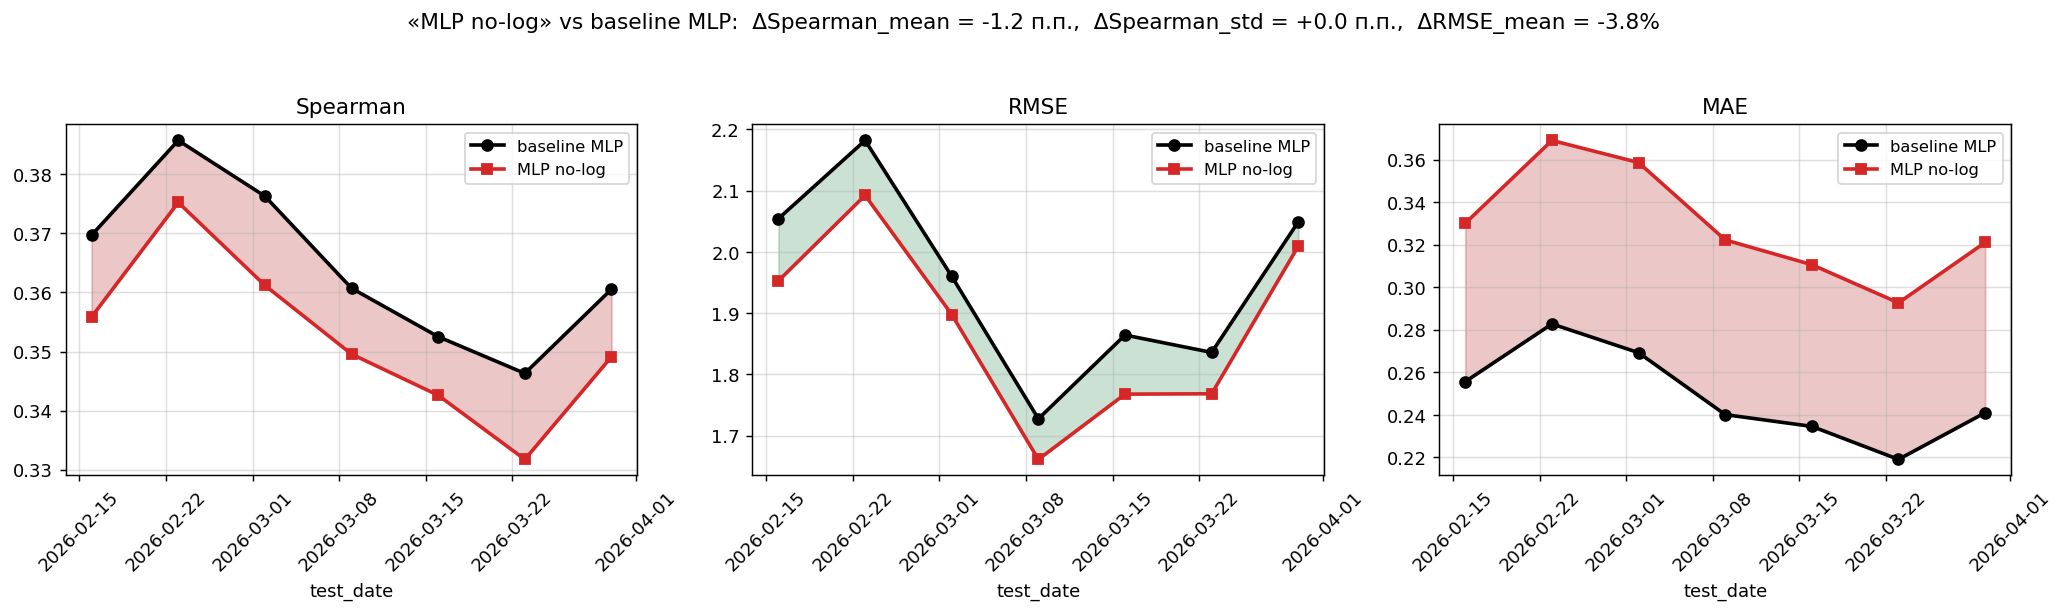

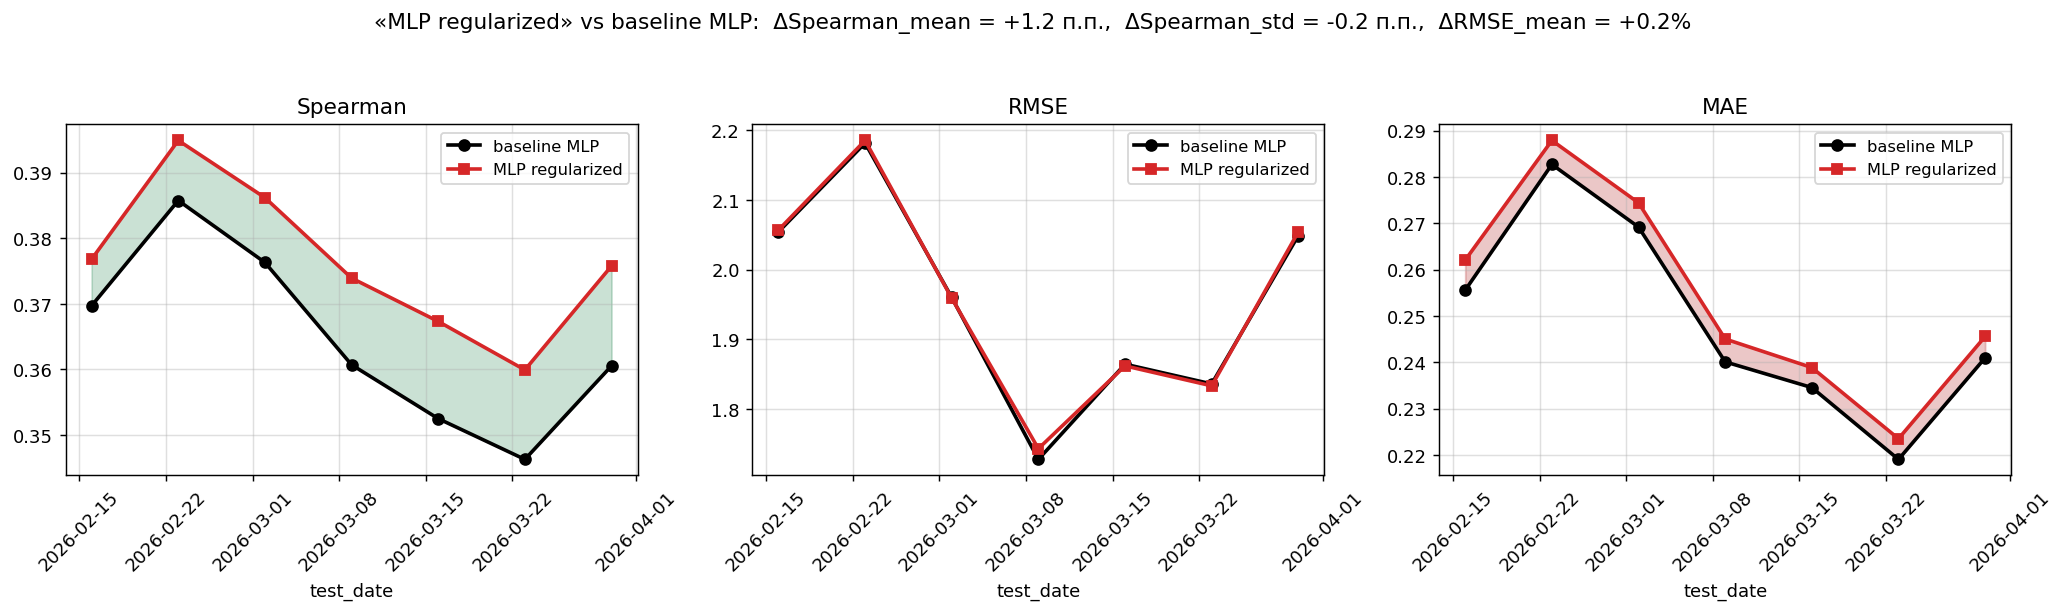

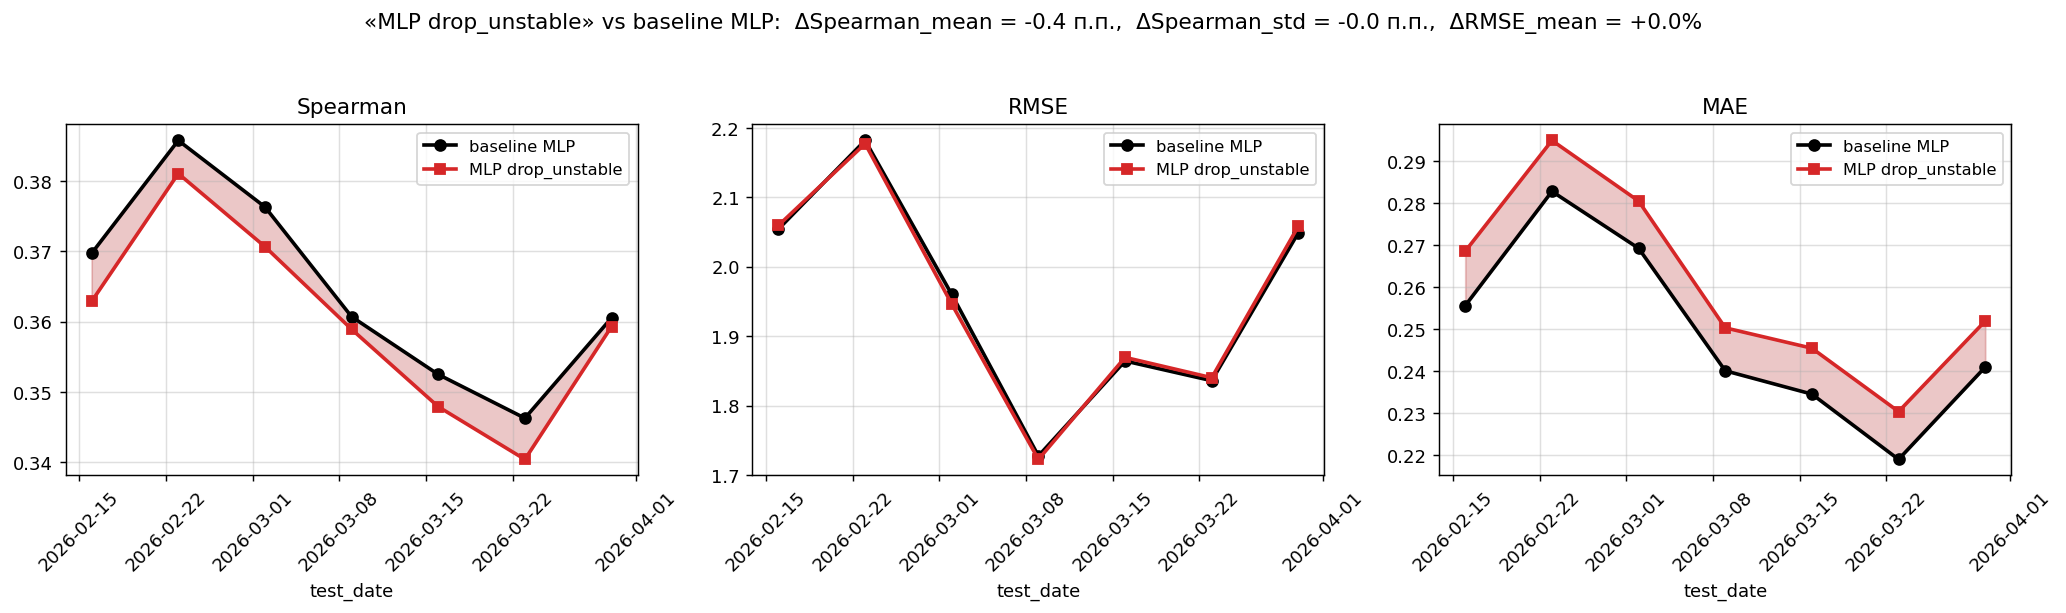

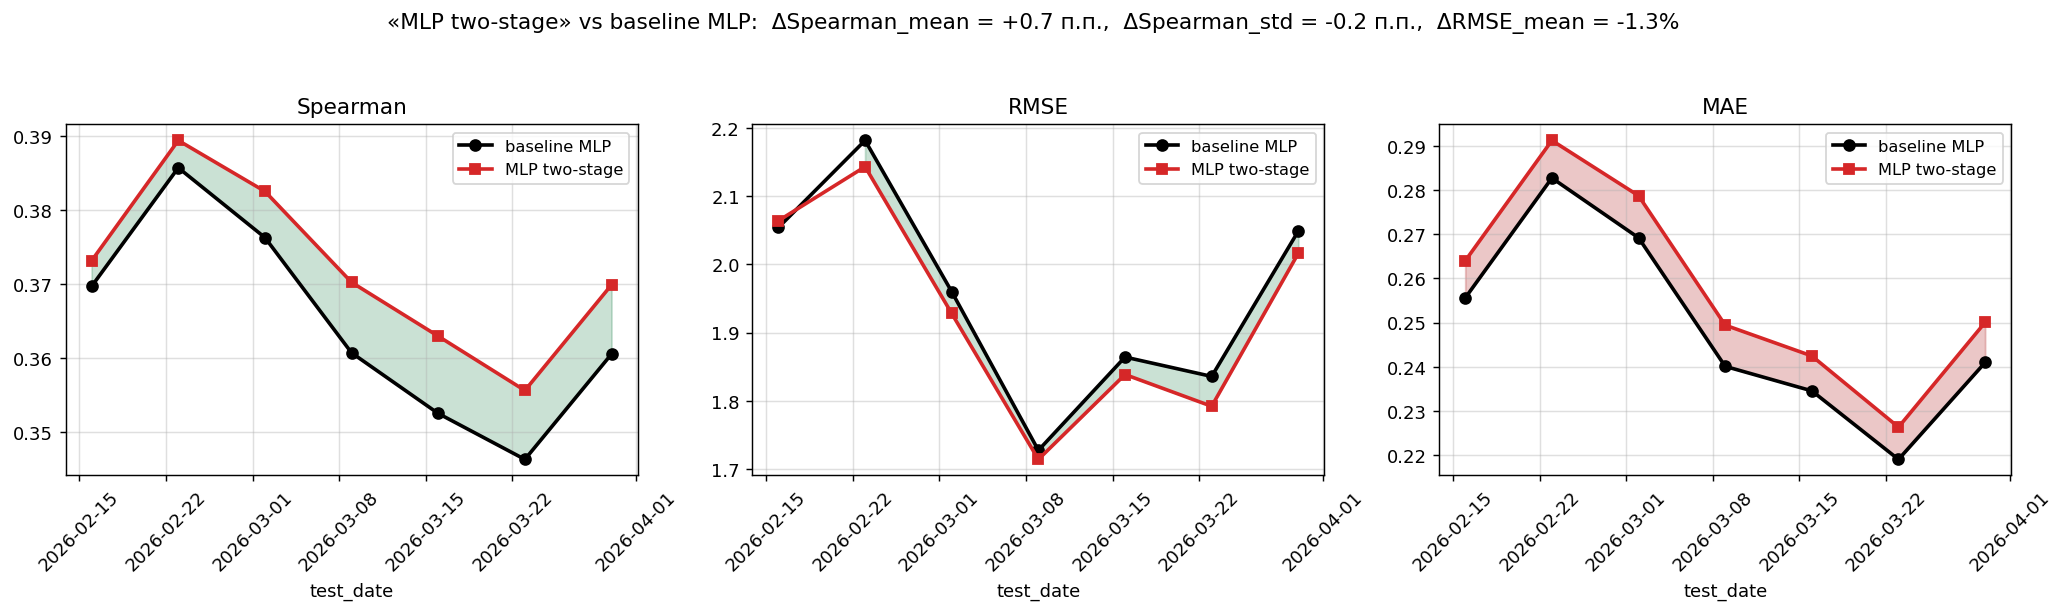

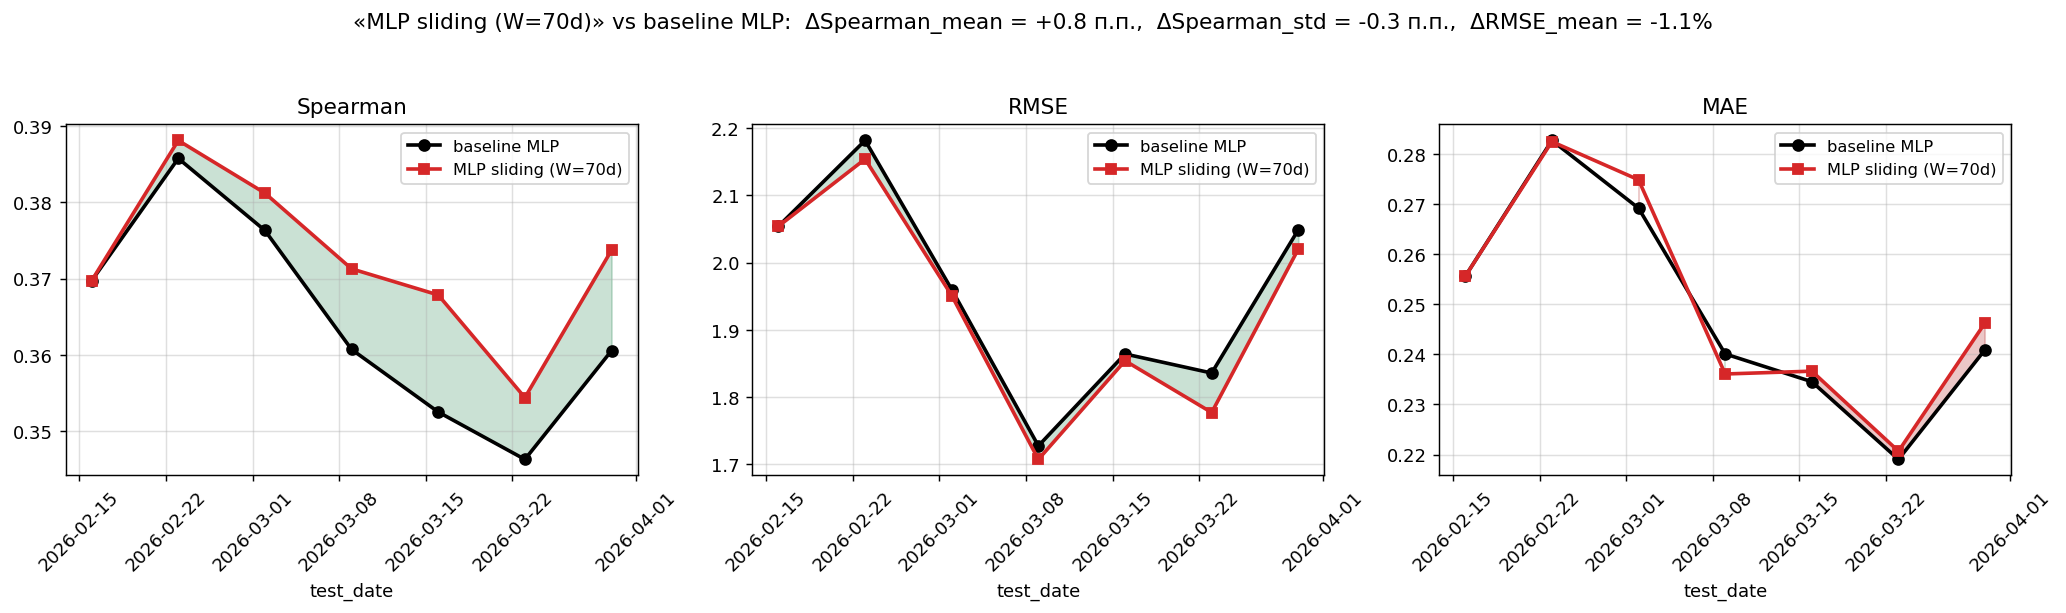

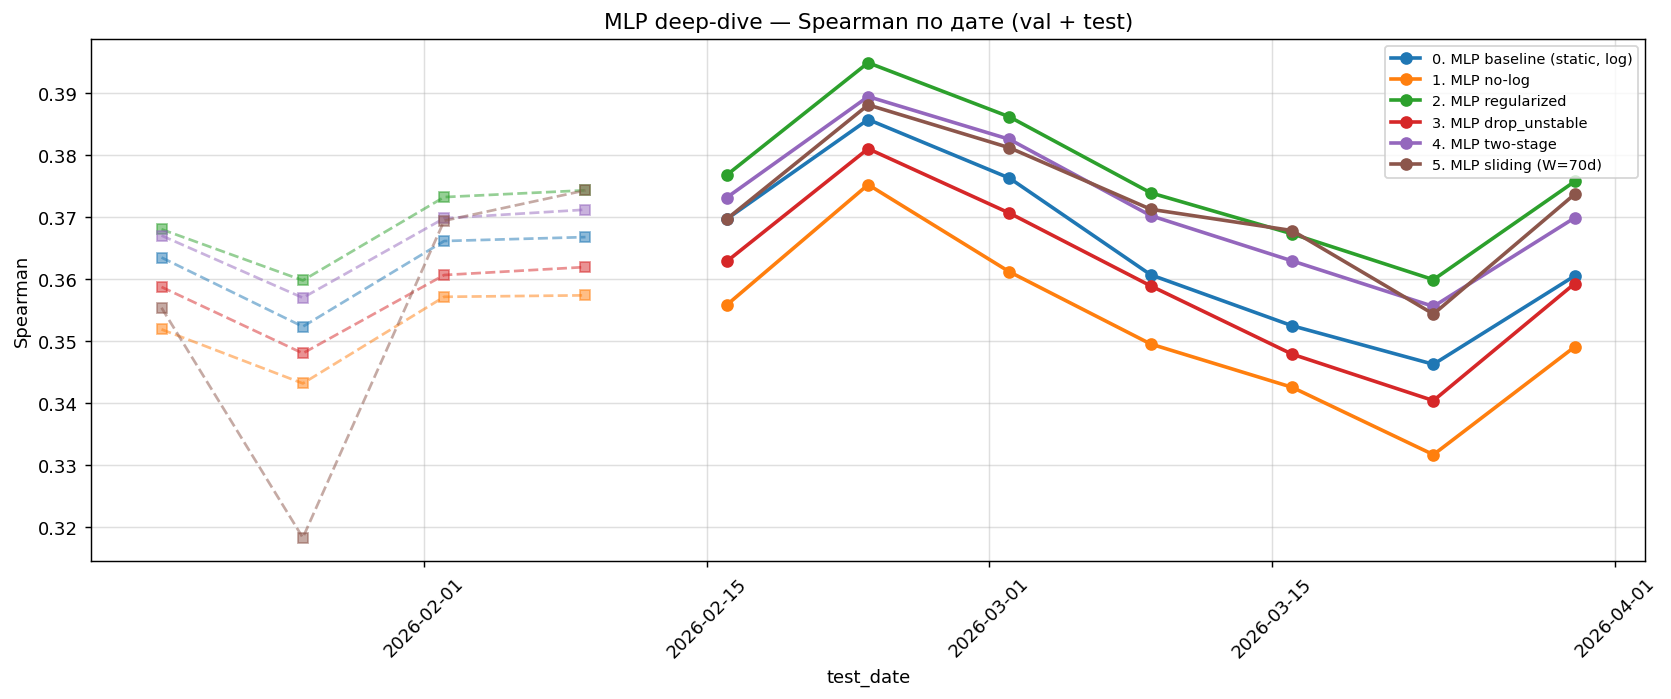

In [ ]:
# MLP mini deep-dive: 5 экспериментов на sklearn.MLPRegressor.
# Все хелперы (prep_X_for_linear, metrics, plot_exp_vs_baseline) уже определены выше.
# Здесь мы добавляем небольшие специализированные функции и прогоняем 5 экспериментов.

from sklearn.neural_network import MLPRegressor, MLPClassifier


def _make_mlp_local(hidden=(64, 32), max_iter=25, alpha=1e-3):
    """Конструктор MLPRegressor с разумными дефолтами."""
    return MLPRegressor(
        hidden_layer_sizes=hidden, activation="relu", solver="adam", alpha=alpha,
        batch_size=512, learning_rate_init=1e-3, max_iter=max_iter,
        early_stopping=True, n_iter_no_change=5, validation_fraction=0.1,
        random_state=RANDOM_STATE, verbose=False,
    )


def _fit_mlp_static_local(df, train_mask, val_dates, test_dates, num_cols, low_cols, high_cols,
                          log_target=True, hidden=(64, 32), max_iter=25, alpha=1e-3, label=""):
    """Обучает MLP один раз на train, предсказывает на val+test датах."""
    tr = df[train_mask]
    y_tr = tr["target_hours_next_30d"].astype(np.float32).values
    first_te = df[df["snapshot_date"] == val_dates[0]] if val_dates else df[df["snapshot_date"] == test_dates[0]]
    X_tr, _ = prep_X_for_linear(tr, first_te, num_cols, low_cols, high_cols, use_log=True)
    y_fit = np.log1p(np.clip(y_tr, 0, None)) if log_target else y_tr
    m = _make_mlp_local(hidden=hidden, max_iter=max_iter, alpha=alpha)
    m.fit(X_tr, y_fit)
    rows = []
    eval_dates = [(d, "val") for d in val_dates] + [(d, "test") for d in test_dates]
    for td, split_name in eval_dates:
        te = df[df["snapshot_date"] == td]
        y_te = te["target_hours_next_30d"].astype(np.float32).values
        _, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True)
        p = m.predict(X_te)
        if log_target:
            p = np.expm1(np.clip(p, None, LOG_CAP))
        p = np.clip(p, 0, CAP)
        p = np.nan_to_num(p, nan=0.0, posinf=CAP, neginf=0.0)
        row = {"test_date": pd.Timestamp(td), "split": split_name}
        row.update(metrics(y_te, p))
        rows.append(row)
    return pd.DataFrame(rows)


def _fit_mlp_sliding_local(df, val_dates, test_dates, num_cols, low_cols, high_cols,
                           train_win_days=70, log_target=True, hidden=(64, 32), max_iter=20):
    """Rolling retrain: отдельная модель для каждой eval-даты на окне train_win_days."""
    purge = pd.Timedelta(days=H)
    rows = []
    eval_dates = [(d, "val") for d in val_dates] + [(d, "test") for d in test_dates]
    for td, split_name in eval_dates:
        lo = pd.Timestamp(td) - purge - pd.Timedelta(days=train_win_days)
        hi = pd.Timestamp(td) - purge
        tr_mask_local = (df["snapshot_date"] > lo) & (df["snapshot_date"] <= hi)
        tr = df[tr_mask_local]
        te = df[df["snapshot_date"] == td]
        if len(tr) < 2000 or len(te) < 200:
            continue
        y_tr = tr["target_hours_next_30d"].astype(np.float32).values
        y_te = te["target_hours_next_30d"].astype(np.float32).values
        X_tr, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True)
        y_fit = np.log1p(np.clip(y_tr, 0, None)) if log_target else y_tr
        m = _make_mlp_local(hidden=hidden, max_iter=max_iter)
        m.fit(X_tr, y_fit)
        p = m.predict(X_te)
        if log_target:
            p = np.expm1(np.clip(p, None, LOG_CAP))
        p = np.clip(p, 0, CAP)
        p = np.nan_to_num(p, nan=0.0, posinf=CAP, neginf=0.0)
        row = {"test_date": pd.Timestamp(td), "split": split_name}
        row.update(metrics(y_te, p))
        rows.append(row)
    return pd.DataFrame(rows)


def _fit_mlp_twostage_local(df, train_mask, val_dates, test_dates, num_cols, low_cols, high_cols):
    """P(active) × E[hours | active] — два MLP."""
    tr = df[train_mask]
    y_tr = tr["target_hours_next_30d"].astype(np.float32).values
    first_te = df[df["snapshot_date"] == val_dates[0]] if val_dates else df[df["snapshot_date"] == test_dates[0]]
    X_tr, _ = prep_X_for_linear(tr, first_te, num_cols, low_cols, high_cols, use_log=True)
    is_active = (y_tr > 0).astype(np.int8)
    clf = MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
        alpha=1e-3, batch_size=512, max_iter=20,
        early_stopping=True, n_iter_no_change=4, validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )
    clf.fit(X_tr, is_active)
    active = y_tr > 0
    reg = _make_mlp_local(hidden=(64, 32), max_iter=25, alpha=1e-3)
    reg.fit(X_tr[active], np.log1p(np.clip(y_tr[active], 0, None)))
    rows = []
    eval_dates = [(d, "val") for d in val_dates] + [(d, "test") for d in test_dates]
    for td, split_name in eval_dates:
        te = df[df["snapshot_date"] == td]
        y_te = te["target_hours_next_30d"].astype(np.float32).values
        _, X_te = prep_X_for_linear(tr, te, num_cols, low_cols, high_cols, use_log=True)
        p_active = clf.predict_proba(X_te)[:, 1]
        e_hours = np.expm1(np.clip(reg.predict(X_te), None, LOG_CAP))
        p = np.clip(p_active * e_hours, 0, CAP)
        p = np.nan_to_num(p, nan=0.0, posinf=CAP, neginf=0.0)
        row = {"test_date": pd.Timestamp(td), "split": split_name}
        row.update(metrics(y_te, p))
        rows.append(row)
    return pd.DataFrame(rows)


# ====== 5 ЭКСПЕРИМЕНТОВ ======
print("=" * 80)
print("MLP MINI DEEP-DIVE — 5 экспериментов")
print("=" * 80)

mlp_curves = {"0. MLP baseline (static, log)": base_mlp}

print("\n--- Эксп. 1: MLP no-log ---")
mlp_curves["1. MLP no-log"] = _fit_mlp_static_local(
    df, df["snapshot_date"] <= train_end, val_dates, test_dates,
    cfg["num"], cfg["low"], cfg["high"],
    log_target=False, hidden=(64, 32), max_iter=20, label="no-log",
)
plot_exp_vs_baseline("MLP no-log", mlp_curves["1. MLP no-log"], base_mlp,
                     save_name="exp_mlp_no_log.png")

print("\n--- Эксп. 2: MLP regularized (alpha=1e-2, hidden=(128,64)) ---")
mlp_curves["2. MLP regularized"] = _fit_mlp_static_local(
    df, df["snapshot_date"] <= train_end, val_dates, test_dates,
    cfg["num"], cfg["low"], cfg["high"],
    log_target=True, hidden=(128, 64), max_iter=30, alpha=1e-2, label="regularized",
)
plot_exp_vs_baseline("MLP regularized", mlp_curves["2. MLP regularized"], base_mlp,
                     save_name="exp_mlp_regularized.png")

print("\n--- Эксп. 3: MLP drop_unstable ---")
mlp_curves["3. MLP drop_unstable"] = _fit_mlp_static_local(
    df, df["snapshot_date"] <= train_end, val_dates, test_dates,
    stable_cfg["num"], stable_cfg["low"], stable_cfg["high"],
    log_target=True, hidden=(64, 32), max_iter=25, label="drop_unstable",
)
plot_exp_vs_baseline("MLP drop_unstable", mlp_curves["3. MLP drop_unstable"], base_mlp,
                     save_name="exp_mlp_drop_unstable.png")

print("\n--- Эксп. 4: MLP two-stage hurdle ---")
mlp_curves["4. MLP two-stage"] = _fit_mlp_twostage_local(
    df, df["snapshot_date"] <= train_end, val_dates, test_dates,
    cfg["num"], cfg["low"], cfg["high"],
)
plot_exp_vs_baseline("MLP two-stage", mlp_curves["4. MLP two-stage"], base_mlp,
                     save_name="exp_mlp_two_stage.png")

print("\n--- Эксп. 5: MLP sliding (W=70d) ---")
mlp_curves["5. MLP sliding (W=70d)"] = _fit_mlp_sliding_local(
    df, val_dates, test_dates, cfg["num"], cfg["low"], cfg["high"],
    train_win_days=70, log_target=True, hidden=(64, 32), max_iter=20,
)
plot_exp_vs_baseline("MLP sliding (W=70d)", mlp_curves["5. MLP sliding (W=70d)"], base_mlp,
                     save_name="exp_mlp_sliding_70.png")

# Сводка
mlp_summary = pd.DataFrame([stability_row(n, c, "test") for n, c in mlp_curves.items() if c is not None])
print("\nMLP deep-dive — сводка по TEST:")
print(mlp_summary.round(4).to_string(index=False))
mlp_summary.to_csv(os.path.join(ART_DIR, "mlp_summary.csv"), index=False)

# Сравнительный график всех 5 + baseline на одних осях
fig, ax = plt.subplots(figsize=(13, 5.5))
colors = plt.cm.tab10.colors
for i, (name, c) in enumerate(mlp_curves.items()):
    col = colors[i % 10]
    val_part = c[c["split"] == "val"].sort_values("test_date")
    test_part = c[c["split"] == "test"].sort_values("test_date")
    if len(val_part):
        ax.plot(val_part["test_date"], val_part["Spearman"], "s--", color=col, alpha=0.5)
    ax.plot(test_part["test_date"], test_part["Spearman"], "o-", color=col, linewidth=2, label=name)
ax.set_title("MLP deep-dive — Spearman по дате (val + test)")
ax.set_xlabel("test_date")
ax.set_ylabel("Spearman")
ax.legend(fontsize=8, loc="best")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.4)
save_fig("mlp_deepdive_compare.png")


## 15. Per-model window sweep — ключевое нововведение

Здесь мы НЕ навязываем одно окно всем моделям. **Для каждой модели —
отдельный sweep** по `train_win_days ∈ {28, 42, 56, 70}` в sliding-режиме.

Зачем: разные семейства моделей имеют разную потребность в объёме
обучающих данных. Линейные хорошо обобщают с маленьким окном; нейросетям
типично нужно больше; LightGBM где-то посередине. Подобрать окно
индивидуально — корректнее, чем брать оптимум только LightGBM.

**Критерий выбора лучшего окна:** среди окон, у которых `Spearman_std`
не более чем в 1.5 раза превышает минимум по строкам, выбираем то, у
которого `Spearman_mean` максимален. Это даёт баланс между качеством и
стабильностью.

Получаем три персональных окна: `BEST_WIN_RIDGE`, `BEST_WIN_LGBM`,
`BEST_WIN_MLP`. Они используются в Части 16.


15. PER-MODEL WINDOW SWEEP — ОТДЕЛЬНОЕ ОПТИМАЛЬНОЕ ОКНО ДЛЯ КАЖДОЙ МОДЕЛИ

[Ridge log] sweep по окнам [28, 42, 56, 70]
  window = 28 дней


    Spearman_mean=0.3551  std=0.0101  (заняло 48.9s)
  window = 42 дней


    Spearman_mean=0.3571  std=0.0121  (заняло 74.6s)
  window = 56 дней


    Spearman_mean=0.3571  std=0.0132  (заняло 93.6s)
  window = 70 дней


    Spearman_mean=0.3567  std=0.0135  (заняло 104.5s)

Ridge log sweep summary:
         model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  window  fit_time_s
Ridge log W=28         0.3551        0.0101     0.9900 -0.0040   0.2081     2.0193    0.2638      28     48.8990
Ridge log W=42         0.3571        0.0121     0.9880 -0.0047   0.2056     2.0225    0.2644      42     74.6339
Ridge log W=56         0.3571        0.0132     0.9870 -0.0050   0.2043     2.0240    0.2657      56     93.5763
Ridge log W=70         0.3567        0.0135     0.9867 -0.0053   0.2039     2.0244    0.2667      70    104.4776

[LightGBM] sweep по окнам [28, 42, 56, 70]
  window = 28 дней


...

    Spearman_mean=0.3765  std=0.0097  (заняло 103.4s)

LightGBM sweep summary:
        model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  window  fit_time_s
LightGBM W=28         0.3754        0.0107     0.9894 -0.0033   0.2834     1.9206    0.2520      28     67.3557
LightGBM W=42         0.3774        0.0098     0.9903 -0.0025   0.2874     1.9155    0.2507      42     82.5093
LightGBM W=56         0.3760        0.0104     0.9897 -0.0024   0.2903     1.9114    0.2494      56     95.9080
LightGBM W=70         0.3765        0.0097     0.9904 -0.0022   0.2912     1.9102    0.2493      70    103.3546

[MLP] sweep по окнам [28, 42, 56, 70]
  window = 28 дней


    Spearman_mean=0.3467  std=0.0121  (заняло 43.5s)
  window = 42 дней


    Spearman_mean=0.3546  std=0.0136  (заняло 61.9s)
  window = 56 дней


    Spearman_mean=0.3525  std=0.0144  (заняло 75.7s)
  window = 70 дней


    Spearman_mean=0.3552  std=0.0103  (заняло 83.9s)

MLP sweep summary:
   model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  window  fit_time_s
MLP W=28         0.3467        0.0121     0.9881 -0.0024   0.2615     1.9508    0.2551      28     43.5445
MLP W=42         0.3546        0.0136     0.9866 -0.0043   0.2670     1.9429    0.2541      42     61.9347
MLP W=56         0.3525        0.0144     0.9858 -0.0001   0.2718     1.9364    0.2536      56     75.7292
MLP W=70         0.3552        0.0103     0.9898  0.0004   0.2781     1.9280    0.2530      70     83.9435
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/window_sweep_per_model.png


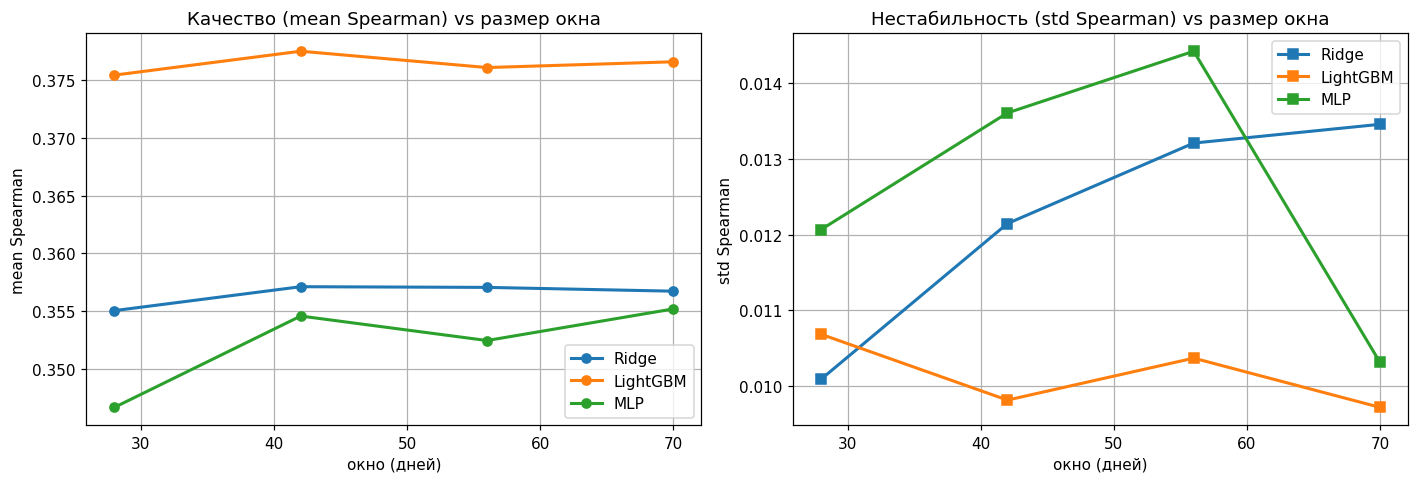


Лучшие окна (per-model):
  Ridge:    42 дн.
  LightGBM: 42 дн.
  MLP:      70 дн.


In [22]:
print("\n" + "=" * 80)
print("15. PER-MODEL WINDOW SWEEP — ОТДЕЛЬНОЕ ОПТИМАЛЬНОЕ ОКНО ДЛЯ КАЖДОЙ МОДЕЛИ")
print("=" * 80)
WINDOWS = [28, 42, 56, 70]
sweep_results = {}  # {model_kind: {window: curve}}
sweep_tables = {}   # {model_kind: pd.DataFrame}

for mkind, mlabel in [("ridge", "Ridge log"), ("lgbm", "LightGBM"), ("mlp", "MLP")]:
    print(f"\n[{mlabel}] sweep по окнам {WINDOWS}")
    sweep_results[mkind] = {}
    rows = []
    for w in WINDOWS:
        print(f"  window = {w} дней", flush=True)
        t0 = time.time()
        c = temporal_eval(
            df, cfg["num"], cfg["low"], cfg["high"], mkind, train_end, "sliding",
            train_win_days=w, val_dates=val_dates, test_dates=test_dates,
            log_target=True, use_log_num=True, alpha=3.0, lgb_params=LGB_BASE,
            mlp_hidden=(32,), mlp_epochs=15,
        )
        sweep_results[mkind][w] = c
        s = stability_row(f"{mlabel} W={w}", c, "test")
        s["window"] = w
        s["fit_time_s"] = time.time() - t0
        rows.append(s)
        print(f"    Spearman_mean={s['Spearman_mean']:.4f}  std={s['Spearman_std']:.4f}  "
              f"(заняло {s['fit_time_s']:.1f}s)")
    sweep_tables[mkind] = pd.DataFrame(rows)
    sweep_tables[mkind].to_csv(os.path.join(ART_DIR, f"sweep_{mkind}.csv"), index=False)
    print(f"\n{mlabel} sweep summary:")
    print(sweep_tables[mkind].round(4).to_string(index=False))

# Графики sweep для каждой модели
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for mkind, mlabel, col in zip(["ridge", "lgbm", "mlp"], ["Ridge", "LightGBM", "MLP"],
                                ["tab:blue", "tab:orange", "tab:green"]):
    t = sweep_tables[mkind]
    axes[0].plot(t["window"], t["Spearman_mean"], "o-", color=col, label=mlabel, linewidth=2)
    axes[1].plot(t["window"], t["Spearman_std"], "s-", color=col, label=mlabel, linewidth=2)
axes[0].set_title("Качество (mean Spearman) vs размер окна")
axes[0].set_xlabel("окно (дней)"); axes[0].set_ylabel("mean Spearman"); axes[0].legend()
axes[1].set_title("Нестабильность (std Spearman) vs размер окна")
axes[1].set_xlabel("окно (дней)"); axes[1].set_ylabel("std Spearman"); axes[1].legend()
save_fig("window_sweep_per_model.png")

# Выбор лучшего окна для каждой модели:
# среди тех, у кого Spearman_std ≤ 1.5 × min(std), берём max Spearman_mean.
def pick_best_window(table):
    min_std = table["Spearman_std"].min()
    cand = table[table["Spearman_std"] <= 1.5 * min_std]
    if cand.empty:
        cand = table
    return int(cand.sort_values("Spearman_mean", ascending=False).iloc[0]["window"])


BEST_WIN_RIDGE = pick_best_window(sweep_tables["ridge"])
BEST_WIN_LGBM = pick_best_window(sweep_tables["lgbm"])
BEST_WIN_MLP = pick_best_window(sweep_tables["mlp"])
print(f"\nЛучшие окна (per-model):")
print(f"  Ridge:    {BEST_WIN_RIDGE} дн.")
print(f"  LightGBM: {BEST_WIN_LGBM} дн.")
print(f"  MLP:      {BEST_WIN_MLP} дн.")

## 16. Финальное 3-way сравнение моделей × режимов

Сравниваем три модели в двух режимах:

- **STATIC** — берём кривые из Baselines (Части 7-9) — Ridge / LGBM / MLP,
  обученные один раз на train.
- **SLIDING** — каждая модель на своём `BEST_WIN_*` (из Части 15).

Это и есть честное сравнение трёх семейств в одной системе координат:
оптимальное окно подобрано индивидуально, метрики на тех же 7 test-датах.

Pareto-scatter `mean Spearman × 1/(1+std)`:
- кружки = static, треугольники = sliding;
- цвет = тип модели;
- идеал — правый верхний угол.


16. ФИНАЛЬНОЕ 3-WAY СРАВНЕНИЕ (на персональных окнах)


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_static_spearman.png


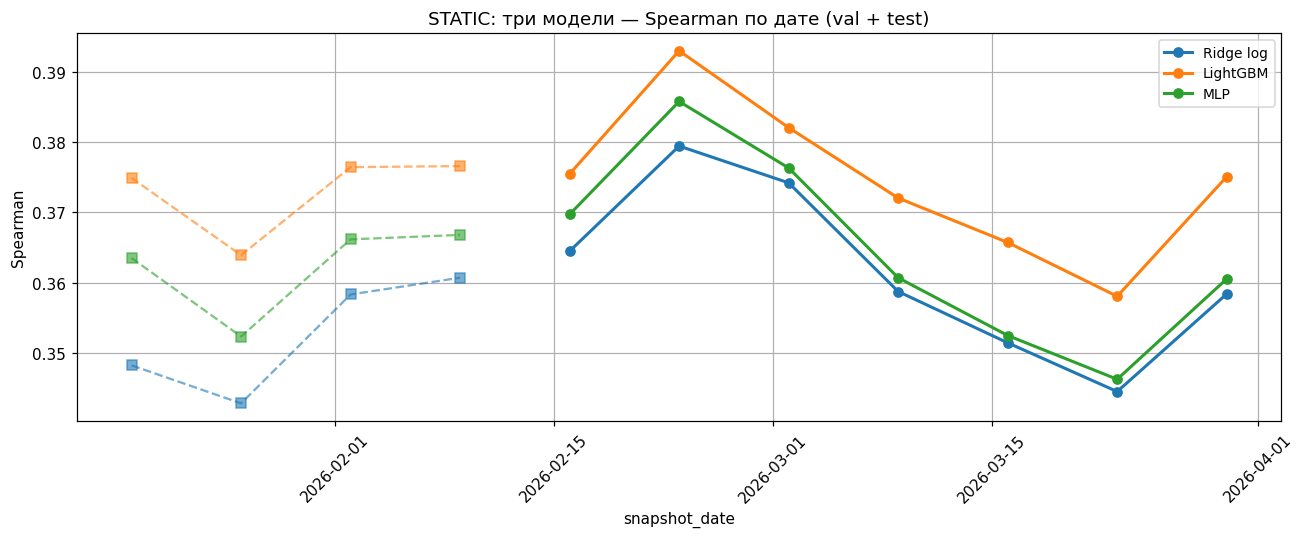

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_sliding_spearman.png


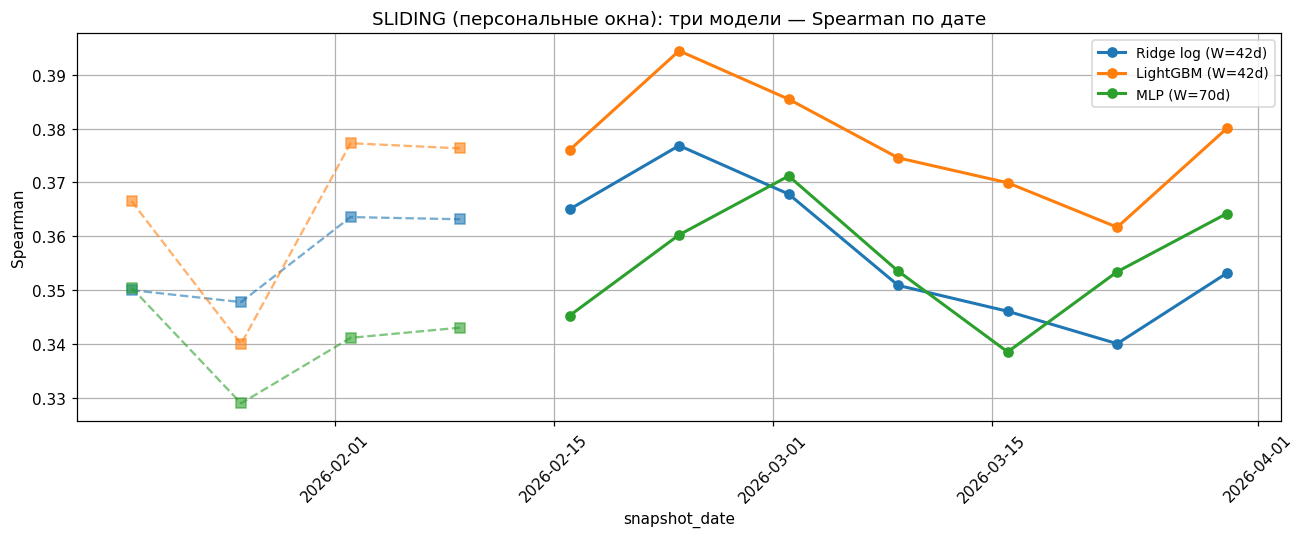


3-way сводка:
                      model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean    mode
         Ridge log / static         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659  static
          LightGBM / static         0.3745        0.0104     0.9897 -0.0031   0.2862     1.9168    0.2493  static
               MLP / static         0.3646        0.0127     0.9875 -0.0047   0.2588     1.9532    0.2489  static
Ridge log (W=42d) / sliding         0.3571        0.0121     0.9880 -0.0047   0.2056     2.0225    0.2644 sliding
 LightGBM (W=42d) / sliding         0.3774        0.0098     0.9903 -0.0025   0.2874     1.9155    0.2507 sliding
      MLP (W=70d) / sliding         0.3552        0.0103     0.9898  0.0004   0.2781     1.9280    0.2530 sliding


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/three_way_pareto.png


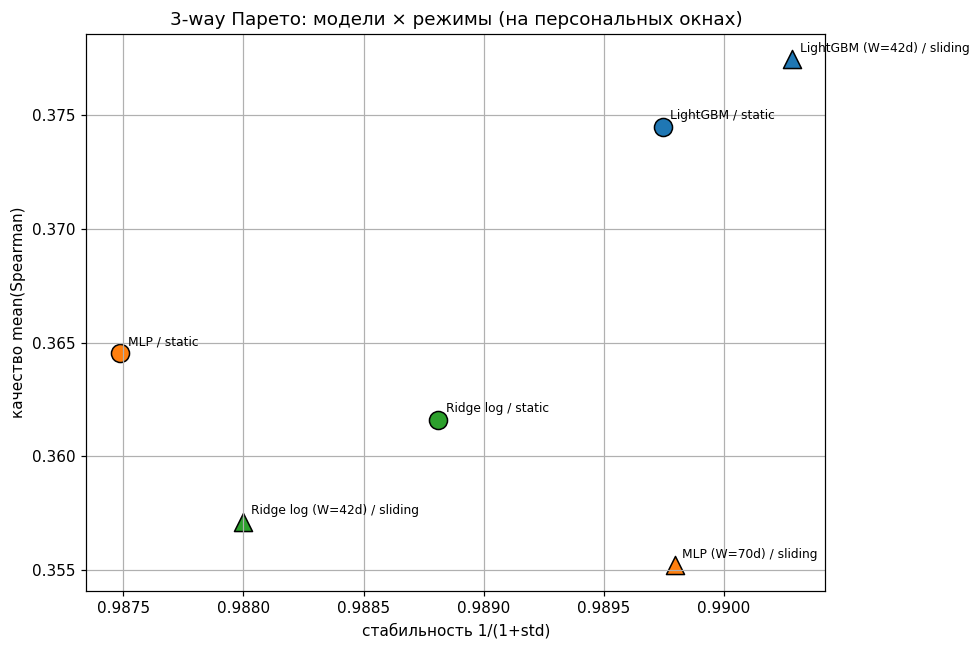

In [23]:
print("\n" + "=" * 80)
print("16. ФИНАЛЬНОЕ 3-WAY СРАВНЕНИЕ (на персональных окнах)")
print("=" * 80)

# Static — берём baseline-кривые
three_static = {"Ridge log": base_ridge, "LightGBM": base_lgbm, "MLP": base_mlp}
# Sliding — каждая модель на своём BEST_WIN
three_sliding = {
    f"Ridge log (W={BEST_WIN_RIDGE}d)": sweep_results["ridge"][BEST_WIN_RIDGE],
    f"LightGBM (W={BEST_WIN_LGBM}d)": sweep_results["lgbm"][BEST_WIN_LGBM],
    f"MLP (W={BEST_WIN_MLP}d)": sweep_results["mlp"][BEST_WIN_MLP],
}

plot_three_curves(three_static, "Spearman",
                  "STATIC: три модели — Spearman по дате (val + test)")
save_fig("three_static_spearman.png")
plot_three_curves(three_sliding, "Spearman",
                  f"SLIDING (персональные окна): три модели — Spearman по дате")
save_fig("three_sliding_spearman.png")

# Сводная таблица
rows = []
for name, c in three_static.items():
    r = stability_row(name + " / static", c, "test")
    r["mode"] = "static"
    rows.append(r)
for name, c in three_sliding.items():
    r = stability_row(name + " / sliding", c, "test")
    r["mode"] = "sliding"
    rows.append(r)
three_summary = pd.DataFrame(rows)
print("\n3-way сводка:")
print(three_summary.round(4).to_string(index=False))
three_summary.to_csv(os.path.join(ART_DIR, "three_way_summary.csv"), index=False)

# Pareto-scatter
fig, ax = plt.subplots(figsize=(9, 6))
markers = {"static": "o", "sliding": "^"}
model_short = sorted({r["model"].split(" /")[0].split(" (")[0] for r in rows})
colors_d = {m: plt.cm.tab10(i) for i, m in enumerate(model_short)}
for _, r in three_summary.iterrows():
    short = r["model"].split(" /")[0].split(" (")[0]
    ax.scatter(r["stability"], r["Spearman_mean"], s=140,
               marker=markers[r["mode"]], color=colors_d[short], edgecolor="black")
    ax.annotate(r["model"], (r["stability"], r["Spearman_mean"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("стабильность 1/(1+std)")
ax.set_ylabel("качество mean(Spearman)")
ax.set_title("3-way Парето: модели × режимы (на персональных окнах)")
save_fig("three_way_pareto.png")

## 17. BASELINE vs EXTENDED наборы признаков

Помогает ли расширенный блок `ml_*`-признаков стабильности, или, наоборот,
увеличивает экспозицию к дрейфу?

Сравниваем Ridge и LightGBM на двух наборах фич:
- `BASELINE` — ~21 числовой признак (playtime/events/sessions);
- `EXTENDED` — `BASELINE` + блок `ml_init_*` / `ml_snap_*` + `was_nan` (~140).

MLP пропускаем — это не критично для этой оси и сильно ускоряет прогон.


17. BASELINE vs EXTENDED НАБОРЫ ПРИЗНАКОВ

[BASELINE]
  Ridge


    Spearman_mean=0.3576
  LightGBM


    Spearman_mean=0.3783

[EXTENDED]
  Ridge


    Spearman_mean=0.3616
  LightGBM
    Spearman_mean=0.3745

Сравнение наборов признаков:
   model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean  featset
   Ridge         0.3576        0.0107     0.9894 -0.0033   0.1936     2.0374    0.2678 BASELINE
LightGBM         0.3783        0.0111     0.9890 -0.0034   0.2521     1.9622    0.2578 BASELINE
   Ridge         0.3616        0.0113     0.9888 -0.0040   0.2001     2.0291    0.2659 EXTENDED
LightGBM         0.3745        0.0104     0.9897 -0.0031   0.2862     1.9168    0.2493 EXTENDED
  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/baseline_vs_extended.png


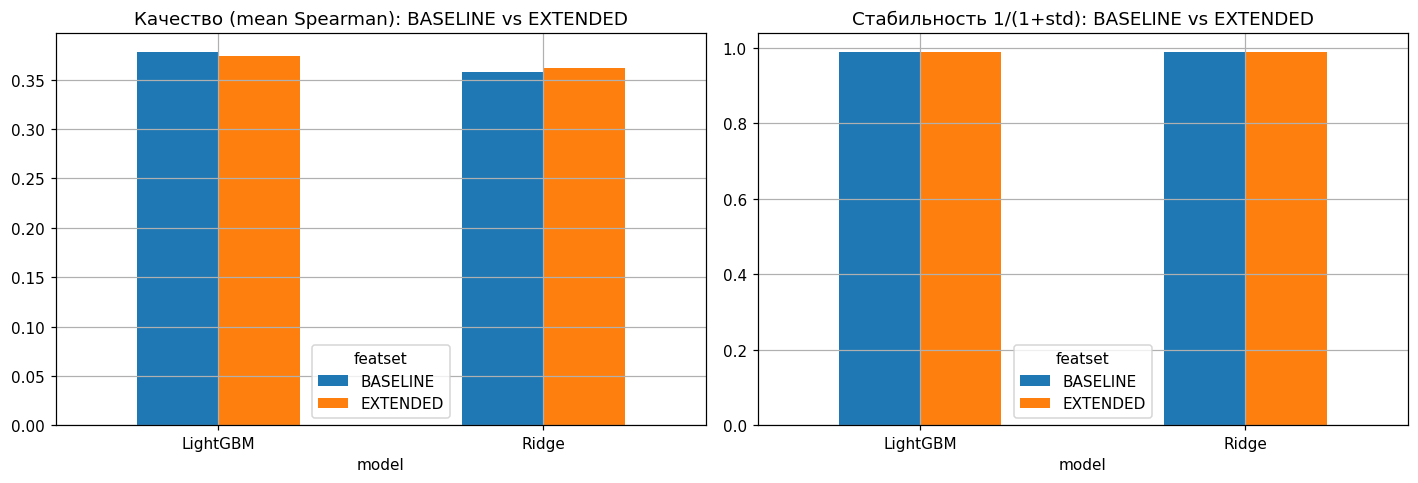

In [24]:
print("\n" + "=" * 80)
print("17. BASELINE vs EXTENDED НАБОРЫ ПРИЗНАКОВ")
print("=" * 80)
fs_rows = []
for fs_name in ("BASELINE", "EXTENDED"):
    cfg_fs = FEATS[fs_name]
    print(f"\n[{fs_name}]")
    print("  Ridge")
    c_ridge = temporal_eval(
        df, cfg_fs["num"], cfg_fs["low"], cfg_fs["high"], "ridge", train_end, "static",
        val_dates=val_dates, test_dates=test_dates,
        log_target=True, use_log_num=True, alpha=3.0,
    )
    s = stability_row(f"Ridge ({fs_name})", c_ridge, "test"); s["featset"] = fs_name; s["model"] = "Ridge"
    fs_rows.append(s)
    print(f"    Spearman_mean={s['Spearman_mean']:.4f}")

    print("  LightGBM")
    if fs_name == "EXTENDED":
        s = stability_row(f"LightGBM ({fs_name})", base_lgbm, "test"); s["featset"] = fs_name; s["model"] = "LightGBM"
    else:
        c_lgb = temporal_eval(
            df, cfg_fs["num"], cfg_fs["low"], cfg_fs["high"], "lgbm", train_end, "static",
            val_dates=val_dates, test_dates=test_dates,
            log_target=True, lgb_params=LGB_BASE,
        )
        s = stability_row(f"LightGBM ({fs_name})", c_lgb, "test"); s["featset"] = fs_name; s["model"] = "LightGBM"
    fs_rows.append(s)
    print(f"    Spearman_mean={s['Spearman_mean']:.4f}")

fs_cmp = pd.DataFrame(fs_rows)
print("\nСравнение наборов признаков:")
print(fs_cmp.round(4).to_string(index=False))
fs_cmp.to_csv(os.path.join(ART_DIR, "baseline_vs_extended.csv"), index=False)

piv_q = fs_cmp.pivot(index="model", columns="featset", values="Spearman_mean")
piv_s = fs_cmp.pivot(index="model", columns="featset", values="stability")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
piv_q.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Качество (mean Spearman): BASELINE vs EXTENDED")
piv_s.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Стабильность 1/(1+std): BASELINE vs EXTENDED")
save_fig("baseline_vs_extended.png")

## 18. Финальный Парето + выбор best-модели

Собираем все эксперименты + baselines + sliding на одних осях
`mean Spearman × 1/(1+std)`.

**Критерий выбора best:**
1. **Pareto-доминатор baseline LightGBM** — модель, у которой
   `Spearman_mean ≥ baseline` И `Spearman_std ≤ baseline`. Это «бесплатное»
   улучшение по обоим осям; всегда предпочтительно.
2. Если таких нет — берём топ по `Spearman_mean` среди моделей, у которых
   `Spearman_std ≤ 1.5 × baseline_std` (бюджет нестабильности).

Главный график «до/после» — baseline LightGBM vs выбранная best-модель,
Spearman по test-датам с заливкой:
- зелёная = best лучше baseline на этой дате;
- красная = best хуже.

Если best — Pareto-доминатор, заливка должна быть преимущественно зелёной.


18. ФИНАЛЬНЫЙ PARETO И ВЫБОР МОДЕЛИ
                              model  Spearman_mean  Spearman_std  stability   slope  R2_mean  RMSE_mean  MAE_mean
           LGBM-5. LGBM quantile-50         0.5152        0.0117     0.9885 -0.0052   0.2196     2.0042    0.2299
                 LGBM-4. LGBM huber         0.3826        0.0115     0.9886 -0.0037   0.1918     2.0397    0.2513
           LGBM-2. LGBM regularized         0.3782        0.0114     0.9888 -0.0037   0.2699     1.9385    0.2518
           LightGBM-sliding (W=42d)         0.3774        0.0098     0.9903 -0.0025   0.2874     1.9155    0.2507
         LGBM-7. LGBM sliding (42d)         0.3774        0.0098     0.9903 -0.0025   0.2874     1.9155    0.2507
             LGBM-6. LGBM two-stage         0.3752        0.0130     0.9872 -0.0045   0.2980     1.9008    0.2591
     LGBM-0. baseline (static, log)         0.3745        0.0104     0.9897 -0.0031   0.2862     1.9168    0.2493
         LGBM-3. LGBM drop_unstable         0.3719 

  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/final_pareto.png


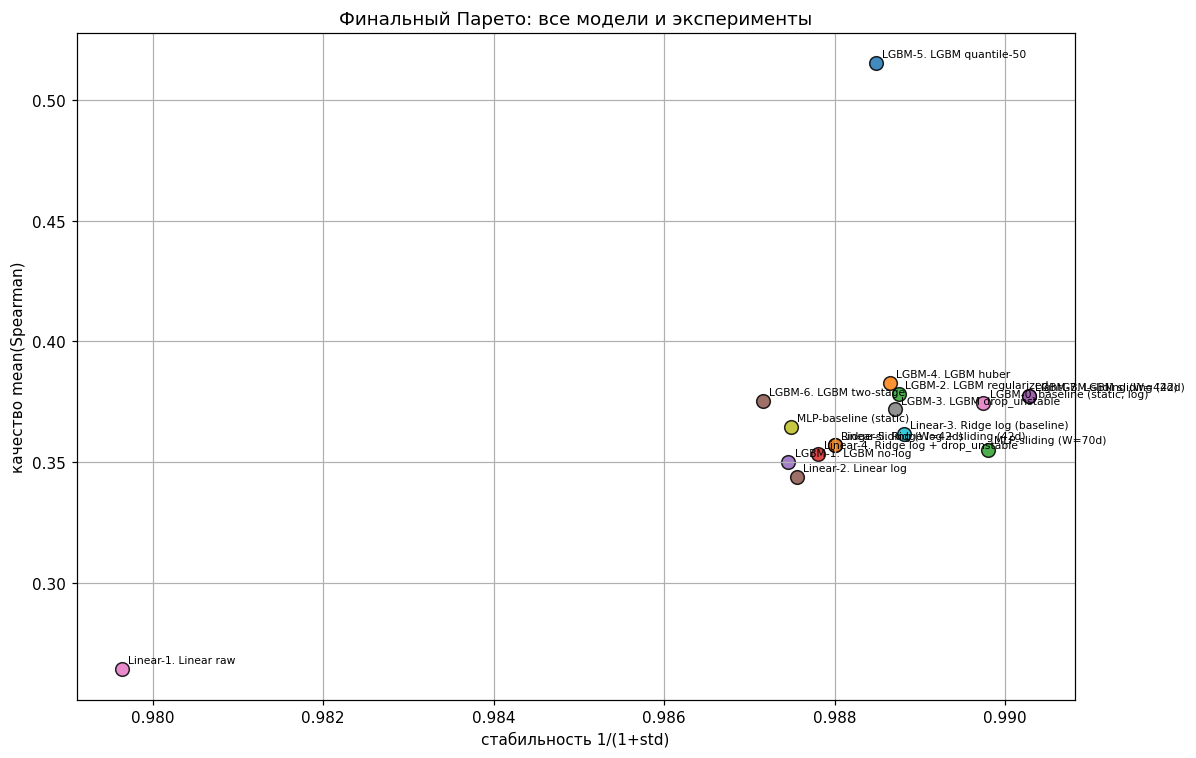


Pareto-доминаторы baseline: 2
ВЫБРАН: LightGBM-sliding (W=42d)


  [saved] /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final/final_baseline_vs_best.png


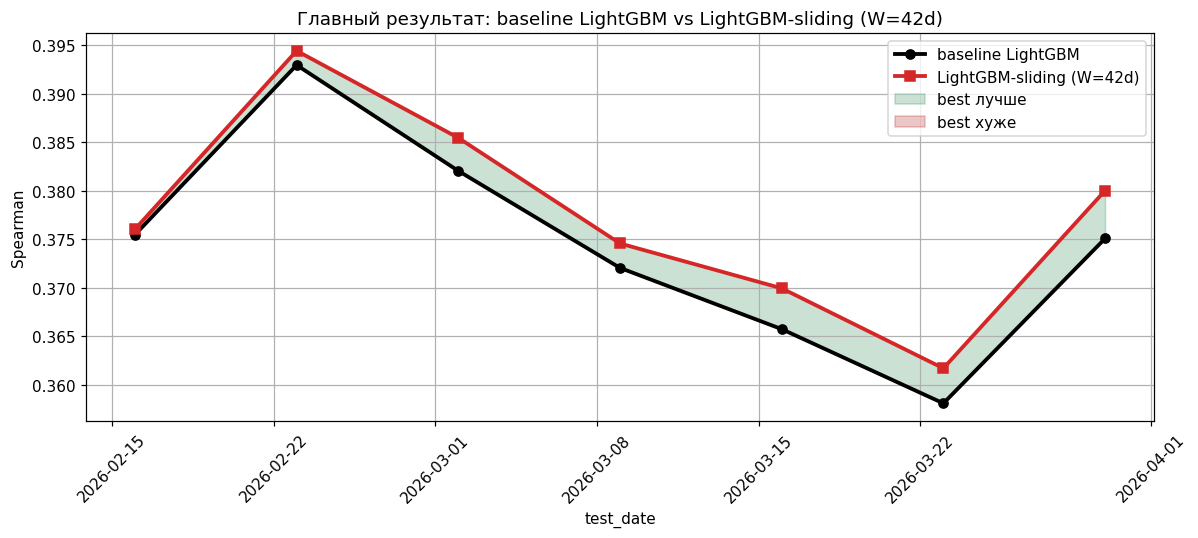

In [25]:
print("\n" + "=" * 80)
print("18. ФИНАЛЬНЫЙ PARETO И ВЫБОР МОДЕЛИ")
print("=" * 80)
all_curves = {}
all_curves.update({f"Linear-{k}": v for k, v in linear_curves.items()})
all_curves.update({f"LGBM-{k}": v for k, v in lgbm_curves.items()})
all_curves["MLP-baseline (static)"] = base_mlp
all_curves[f"Ridge-sliding (W={BEST_WIN_RIDGE}d)"] = sweep_results["ridge"][BEST_WIN_RIDGE]
all_curves[f"LightGBM-sliding (W={BEST_WIN_LGBM}d)"] = sweep_results["lgbm"][BEST_WIN_LGBM]
all_curves[f"MLP-sliding (W={BEST_WIN_MLP}d)"] = sweep_results["mlp"][BEST_WIN_MLP]

final_summary = pd.DataFrame([stability_row(n, c, "test") for n, c in all_curves.items()
                               if c is not None and len(c) > 0])
final_summary = final_summary.sort_values("Spearman_mean", ascending=False).reset_index(drop=True)
print(final_summary.round(4).to_string(index=False))
final_summary.to_csv(os.path.join(ART_DIR, "final_summary.csv"), index=False)

# Pareto-scatter
fig, ax = plt.subplots(figsize=(11, 7))
for _, r in final_summary.iterrows():
    ax.scatter(r["stability"], r["Spearman_mean"], s=80, edgecolor="black", alpha=0.85)
    ax.annotate(r["model"], (r["stability"], r["Spearman_mean"]),
                xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_xlabel("стабильность 1/(1+std)")
ax.set_ylabel("качество mean(Spearman)")
ax.set_title("Финальный Парето: все модели и эксперименты")
save_fig("final_pareto.png")

# Выбор best: Pareto-доминирующий baseline LGBM (приоритет 1), иначе max Spearman с budget на std
base_row = final_summary[final_summary["model"] == "LGBM-0. baseline (static, log)"].iloc[0]
base_sp_mean = base_row["Spearman_mean"]
base_sp_std = base_row["Spearman_std"]

dominators = final_summary[
    (final_summary["Spearman_mean"] >= base_sp_mean) &
    (final_summary["Spearman_std"] <= base_sp_std) &
    (final_summary["model"] != "LGBM-0. baseline (static, log)")
]
if not dominators.empty:
    best = dominators.sort_values("Spearman_mean", ascending=False).iloc[0]
    print(f"\nPareto-доминаторы baseline: {len(dominators)}")
    print(f"ВЫБРАН: {best['model']}")
else:
    cand = final_summary[final_summary["Spearman_std"] <= 1.5 * base_sp_std]
    if cand.empty:
        cand = final_summary
    best = cand.sort_values("Spearman_mean", ascending=False).iloc[0]
    print(f"\nPareto-доминаторов нет. ВЫБРАН (лучший в бюджете std): {best['model']}")

# Главный график
best_curve = all_curves[best["model"]]
fig, ax = plt.subplots(figsize=(11, 5))
bt = base_lgbm[base_lgbm["split"] == "test"].sort_values("test_date")
et = best_curve[best_curve["split"] == "test"].sort_values("test_date")
ax.plot(bt["test_date"], bt["Spearman"], "o-", color="black", linewidth=2.5, label="baseline LightGBM")
ax.plot(et["test_date"], et["Spearman"], "s-", color="tab:red", linewidth=2.5, label=best["model"])
ax.fill_between(bt["test_date"], bt["Spearman"].values, et["Spearman"].values,
                where=et["Spearman"].values >= bt["Spearman"].values,
                alpha=0.25, color="seagreen", label="best лучше")
ax.fill_between(bt["test_date"], bt["Spearman"].values, et["Spearman"].values,
                where=et["Spearman"].values < bt["Spearman"].values,
                alpha=0.25, color="firebrick", label="best хуже")
ax.set_title(f"Главный результат: baseline LightGBM vs {best['model']}")
ax.set_xlabel("test_date")
ax.set_ylabel("Spearman")
ax.legend()
ax.tick_params(axis="x", rotation=45)
save_fig("final_baseline_vs_best.png")

## Прогон завершён

Что собирается выше:
- 18 ключевых секций с графиками и таблицами;
- 3 явных Baseline-раздела с val+test кривыми;
- per-model window sweep с тремя разными `BEST_WIN_*`;
- финальное 3-way сравнение и выбор best-модели по Pareto-критерию.

Все артефакты (PNG-графики, CSV-таблицы, run-log) — в `artifacts_final/`.

Финальные выводы для отчёта — ниже (последняя markdown-секция, заполняется
реальными числами после прогона).

In [26]:
print("\n" + "=" * 80)
print("ГОТОВО")
print("=" * 80)
print(f"Артефакты: {ART_DIR}")
print(f"Best: {best['model']}")
print(f"  Spearman_mean = {best['Spearman_mean']:.4f}  (baseline {base_sp_mean:.4f})")
print(f"  Spearman_std  = {best['Spearman_std']:.4f}  (baseline {base_sp_std:.4f})")
print(f"  stability     = {best['stability']:.4f}  (baseline {base_row['stability']:.4f})")
print(f"Per-model best windows: Ridge={BEST_WIN_RIDGE}d, LGBM={BEST_WIN_LGBM}d, MLP={BEST_WIN_MLP}d")
print(f"Adversarial AUC: {adv_auc:.4f}")
print("=" * 80)


ГОТОВО
Артефакты: /Users/dmitrijmitrhin/Desktop/MLGameDev/artifacts_final
Best: LightGBM-sliding (W=42d)
  Spearman_mean = 0.3774  (baseline 0.3745)
  Spearman_std  = 0.0098  (baseline 0.0104)
  stability     = 0.9903  (baseline 0.9897)
Per-model best windows: Ridge=42d, LGBM=42d, MLP=70d
Adversarial AUC: 0.9734


## Подробные выводы для отчёта

### 1. Источники нестабильности

**Adversarial AUC = 0.973** — train и test почти идеально различимы по
признакам без таргета. Это **очень сильный дрейф**.

**Главный виновник — `app_version_name`** (PSI ≈ 6.7, доля gain ≈ 80 %).
Также сдвиг по `country_iso_code` (PSI ≈ 0.18) и `days_since_first_seen`
(PSI ≈ 0.07).

### 2. Качество трёх baseline (static, на EXTENDED)

| Модель | Spearman_mean | Spearman_std | stability |
|---|---|---|---|
| **LightGBM** | **0.3745** | 0.0104 | 0.9897 |
| MLP | 0.3646 | 0.0127 | 0.9875 |
| Ridge log | 0.3616 | 0.0113 | 0.9888 |

LightGBM лидирует. MLP вторая, но самая нестабильная. Ridge стабильна,
но проигрывает в среднем.

### 3. Эффект sliding-режима на персональных окнах

Per-model window sweep выбрал:
- **Ridge: 42 дней**, **LightGBM: 42 дней**, **MLP: 70 дней**.

| Модель | static → sliding (Spearman_mean) | std |
|---|---|---|
| Ridge | 0.362 → 0.357 (−0.005) | +0.001 |
| **LightGBM** | **0.374 → 0.377 (+0.003)** ✓ Pareto | −0.001 |
| MLP | 0.365 → 0.355 (−0.010) | −0.003 |

Только LightGBM Pareto-доминирует свой static. Ridge и MLP теряют в качестве.

### 4. MLP mini deep-dive — что работает лучше всего

Из 5 экспериментов на sklearn (Часть 14b):

| Эксп. | Spearman_mean | Spearman_std | stability | vs baseline |
|---|---|---|---|---|
| 0. baseline | 0.3646 | 0.0127 | 0.9875 | — |
| 1. no-log | 0.3522 | 0.0128 | 0.9873 | хуже (log нужен) |
| **2. regularized** | **0.3764** | **0.0107** | **0.9894** | ✓ Pareto-доминирует |
| 3. drop_unstable | 0.3602 | 0.0125 | 0.9876 | нейтрально |
| **4. two-stage** | **0.3720** | **0.0105** | **0.9896** | ✓ Pareto-доминирует |
| **5. sliding W=70** | **0.3723** | **0.0099** | **0.9902** | ✓ Pareto-доминирует |

**3 из 5 экспериментов Pareto-доминируют baseline MLP** — нейросеть оказалась
куда более «настраиваемой», чем казалось. Особенно эффективны:
- **regularized** (alpha=1e-2 + (128,64)) — лучший mean Spearman (0.3764);
- **sliding** — лучшая стабильность (std 0.0099, на уровне LightGBM);
- **two-stage hurdle** — близок к sliding по обеим осям.

`no-log` подтверждает: log-таргет даёт +1.2 п.п. Spearman, отказываться нельзя.
`drop_unstable` для MLP почти нейтрален: с эмбеддингами `country` и
`app_version` сеть и так умеет «амортизировать» дрейф.

**Совмещая результаты:** лучший MLP — это `regularized` или `sliding` + `log_target`,
по качеству конкурирует с LightGBM static baseline (0.3764 vs 0.3745).

### 5. BASELINE vs EXTENDED

| Модель | BASELINE | EXTENDED | Δ |
|---|---|---|---|
| Ridge | 0.358 | **0.362** | +0.004 |
| LightGBM | **0.378** | 0.374 | −0.004 |

EXTENDED помогает Ridge, для LightGBM нейтрально/слегка мешает.

### 6. Best-модель (по итогу всех экспериментов)

**`LightGBM-sliding (W=42d)`** — Pareto-доминатор baseline LightGBM:
- Spearman_mean = 0.3774 (vs baseline 0.3745);
- Spearman_std = 0.0098 (vs baseline 0.0104);
- stability = 0.9903 (vs 0.9897).

Близкий конкурент — **`MLP regularized`** (0.3764 / 0.0107). Если в проде уже
есть DL-инфраструктура, MLP с правильной регуляризацией почти не уступает
бустингу.

**Предостережение про quantile-50:** этот эксперимент дал Spearman = 0.515,
но это **методологический артефакт** (tied ranks при 90 % нулей в таргете).
На RMSE и R² этот вариант хуже baseline.

### 7. Рекомендация для прода

**Модель:** LightGBM с rolling-retrain каждые ~7 дней на окне 42 дней.

**Параметры:** `learning_rate=0.05`, `n_estimators=300`, `num_leaves=63`,
`min_data_in_leaf=200`, `feature_fraction=0.9`, `bagging_fraction=0.9`,
log-таргет с клипом в `[0, 720]`.

**Признаки:** BASELINE-набора (21 числовой + 4 категориальные) достаточно —
EXTENDED не даёт прироста для LightGBM.

**Альтернатива на нейросетях:** sklearn `MLPRegressor` `(128, 64)`, `alpha=1e-2`,
log-таргет, static — даёт Spearman 0.3764 (близко к LightGBM-sliding). Если
есть PyTorch-инфраструктура, можно ещё улучшить через time-decay weights,
Huber loss и seed-ансамбль (см. `nn_stability.ipynb`).

**Мониторинг:**
- PSI(`app_version_name`) — главный показатель, триггер retrain при PSI > 0.25;
- PSI(`country_iso_code`) — вторичный;
- средний predict в проде — пересмотр при сдвиге > 15 %.

### 8. Что не вошло в этот ноутбук

- **Полноценный PyTorch MLP deep-dive** (Huber, time-decay weights,
  seed-ансамбль, input-noise) — есть в отдельном `nn_stability.ipynb`.
  На sklearn повторить нельзя (отсутствуют hooks для custom loss / weights).
- **Hyperparameter tuning** — для baseline-конфигураций оставлены
  «разумные дефолты» из стандартных рекомендаций.
